In [1]:
#######################################
## downstream of ilastik analysis
#######################################

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy

from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.color import rgb2gray, rgb2hsv
from skimage.filters import threshold_otsu
#from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, measure, morphology, color
from skimage.draw import rectangle_perimeter

In [3]:
def find_max_gap(idx_col):
    import numpy as np
    
    index_gap = 1
    gap_size2save = 0
    gap_idx_2save = []
    gap_size = 0
    gap_idx = []
    
    nb_id = 0
    for idx in idx_col:
        nb_id = nb_id + 1;
        #print(idx)
        if gap_size == 0: ## gap starting point
            gap_idx.append(idx)
            gap_size = gap_size + 1
            idx_prev = idx
        else:
            diff = idx - idx_prev
            
            if diff > 1 or nb_id == len(idx_col): ## gap ending point
                #print(idx)
                if gap_size2save == 0:
                    gap_size2save = gap_size
                    gap_idx_2save = gap_idx
                else:
                    if gap_size >= gap_size2save:
                        gap_size2save = gap_size
                        gap_idx_2save = gap_idx
                
                gap_size = 0
                gap_idx = []
                index_gap = index_gap + 1
                
            else:
                gap_size = gap_size + 1 ## increase the gap
                gap_idx.append(idx)
                idx_prev = idx
    if index_gap == 1: # in case there is one gap
        gap_size2save = gap_size
        gap_idx_2save = gap_idx
    
    return(gap_idx_2save)

In [6]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/processed/ilastik_batch"
#inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/processed"
#fileName = '675995-LNP1-limb2.jpg'
fileName = '675982-LNP1-limb2_Probabilities.tif'
#fileName = '675953-LNP1-limb1_Probabilities.tif'
#fileName = '675911-LNP3-limb2_Probabilities.tif'

#fileName = "675907-LNP4-limb2_Probabilities.tif"
#fileName = "675911-LNP3-limb1_Probabilities.tif"
#fileName = '675911-LNP3-limb2_Probabilities.tif'
#fileName = '675982-LNP1-limb1_Probabilities.tif'
#fileName = "675930-LNP3-limb2_Probabilities.tif"
#fileName = "675948-LNP2-limb1_Probabilities.tif"
#fileName = "675969-LNP3-limb1_Probabilities.tif"
#fileName = "676002-LNP2-limb1_Probabilities.tif"
#fileName = "675911-LNP3-limb2_Probabilities.tif"

path_results = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/' \
        + 'downstream_ilastik' + '/'
outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)
print(fileName)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/downstream_ilastik/
675982-LNP1-limb2_Probabilities.tif


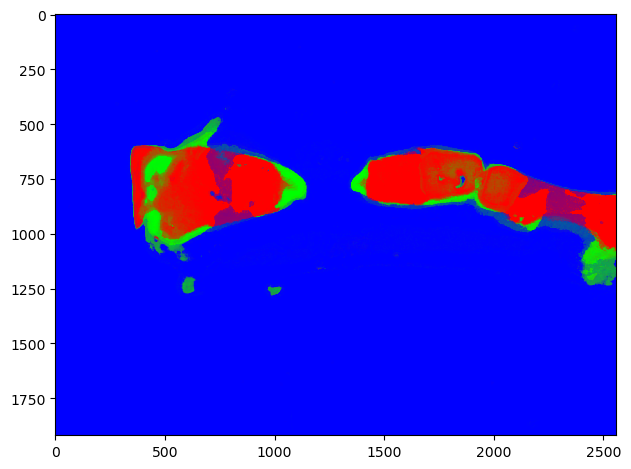

In [7]:
# Load Original Image
img_prob = imread(os.path.join(inputDir, fileName))
imshow(img_prob)

In [8]:
img_prob.shape

(1920, 2560, 3)

In [9]:
bone_mask = img_prob[:, :, 0] > 0.7;
cart_mask = img_prob[:, :, 1] > 0.8;

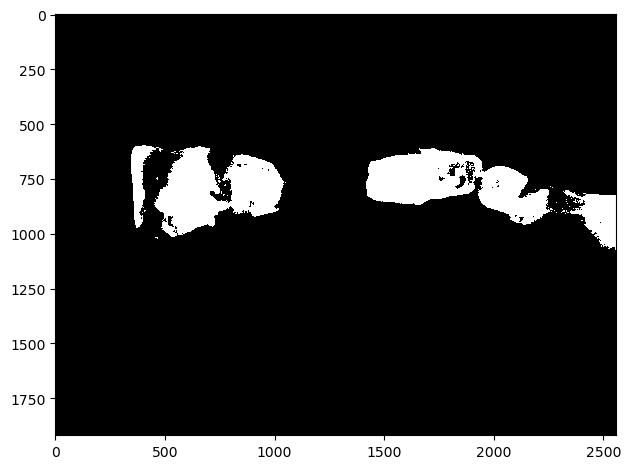

In [10]:
imshow(bone_mask)

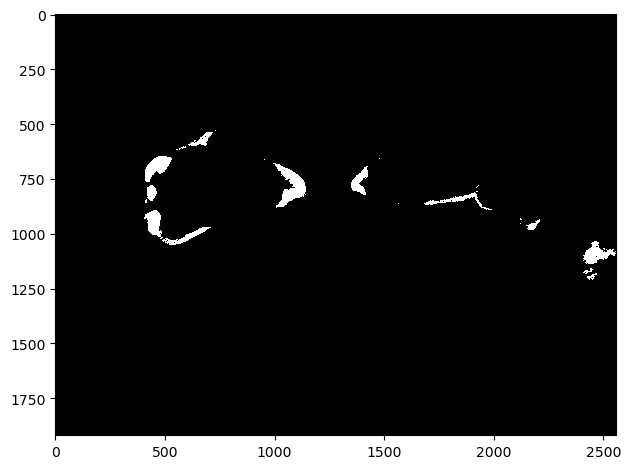

In [16]:
imshow(cart_mask)

In [11]:
bone_mask = morphology.remove_small_objects(bone_mask, min_size=64)

In [12]:
rowsum = bone_mask.sum(axis=1);
idx_row = np.where(rowsum > 0)
colsum = bone_mask.sum(axis=0);
idx_col = np.where(colsum > 0)

In [13]:
bone_mask_cropped = bone_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
cart_mask_cropped = cart_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]

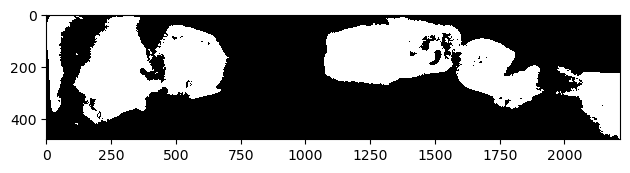

In [14]:
imshow(bone_mask_cropped, cmap="gray")

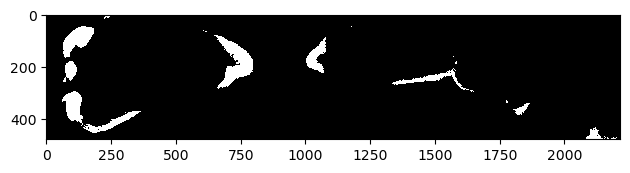

In [15]:
imshow(cart_mask_cropped, cmap="gray")

In [17]:
colsum = bone_mask_cropped.sum(axis=0);
idx_col = np.where(colsum == 0)
colsum2 = cart_mask_cropped.sum(axis = 0)

In [18]:
gap_idx = find_max_gap(idx_col[0])
length_bone = len(gap_idx)

In [19]:
np.min(gap_idx)

np.int64(709)

In [20]:
bone_len = 100
if np.min(gap_idx) < bone_len:
    bone_len = np.min(gap_idx)
bone_mask_gap = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.max(gap_idx) + bone_len)]
cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
#cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]

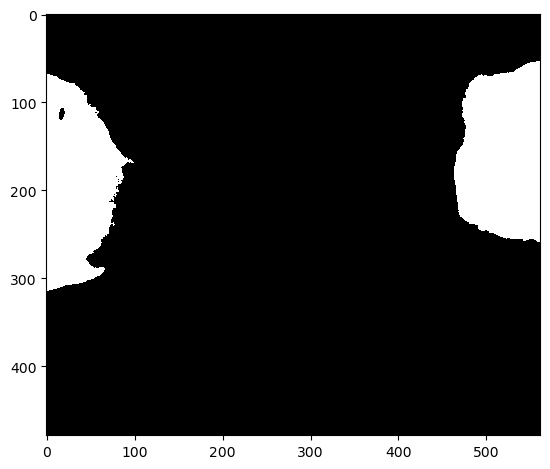

In [21]:
imshow(bone_mask_gap, cmap="gray")

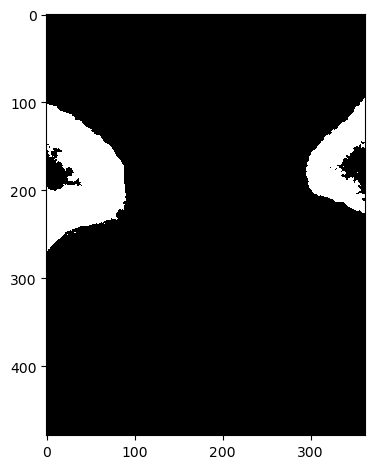

In [22]:
imshow(cart_mask_gap, cmap="gray")

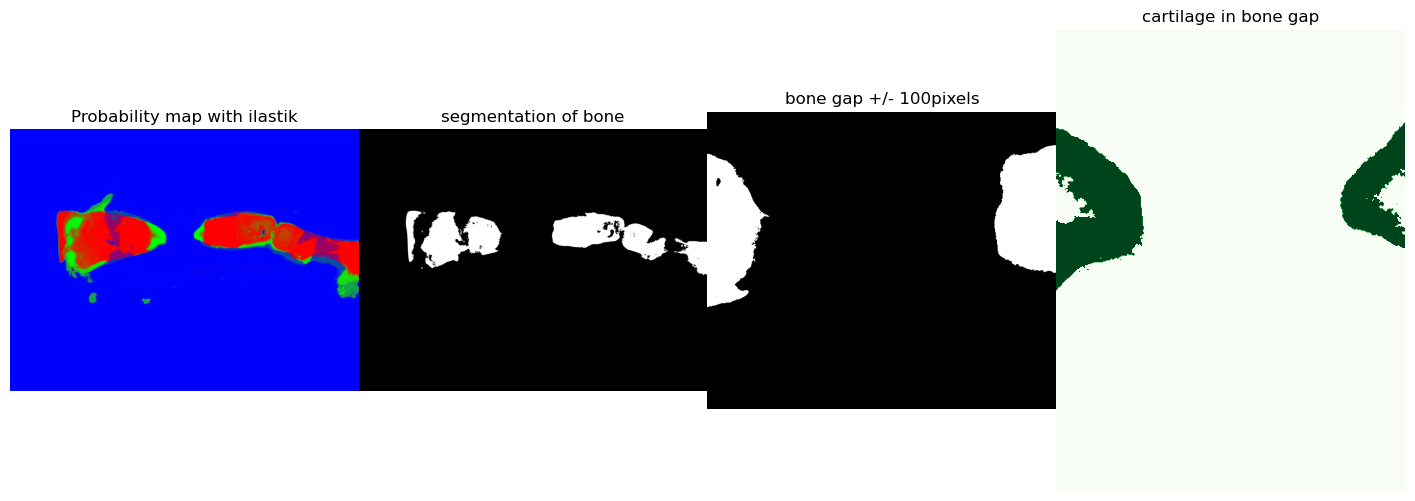

In [23]:
# Plot
fig, ax = plt.subplots(1, 4, figsize=(18, 6))
fig.subplots_adjust(wspace=0)

ax[0].set_title("Probability map with ilastik")
ax[0].imshow(img_prob)
ax[0].set_axis_off()
ax[1].set_title("segmentation of bone")
ax[1].imshow(bone_mask, cmap='gray')
ax[1].set_axis_off()
ax[2].set_title("bone gap +/- 100pixels")
ax[2].imshow(bone_mask_gap, cmap='gray')
ax[2].set_axis_off()

ax[3].set_title("cartilage in bone gap")
ax[3].imshow(cart_mask_gap, cmap='Greens')
ax[3].set_axis_off()


In [55]:
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)

gap_idx_cart = find_max_gap(idx_col_cart[0])
gap_idx_cart
idx_col_cart

(array([], dtype=int64),)

In [56]:
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)
gap_idx_cart = find_max_gap(idx_col_cart[0])
length_gapCart = len(gap_idx_cart)
length_gapCart1 = len(idx_col_cart[0])
print(length_gapCart, length_gapCart1)

0 0


In [57]:
from scipy.signal import argrelextrema
pct_cutPlan = 1/3

In [58]:
bone_left = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.min(gap_idx))]
colsum_left = bone_left.sum(axis=0)
colsum_left = colsum_left[::-1]
#print(colsum_left[0:99])
diff = abs(colsum_left - np.max(colsum_left) * pct_cutPlan)
#print(diff)
#print(diff.argmin(axis=0))
dist_left = argrelextrema(diff, np.less)[0][0]
print(dist_left)

6


In [59]:
bone_right = bone_mask_cropped[:, (np.max(gap_idx)):(np.max(gap_idx) + bone_len)]
colsum_right = bone_right.sum(axis=0)
#colsum_right = colsum_right[::-1]
#print(colsum_right)
diff_right = abs(colsum_right - np.max(colsum_right) * pct_cutPlan)
#print(diff.argmin(axis=0))
dist_right = argrelextrema(diff_right, np.less)[0][0]

print(dist_right)

17


In [60]:
cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)-dist_left):(np.max(gap_idx) + dist_right)]
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)
gap_idx_cart2 = find_max_gap(idx_col_cart[0])
length_gapCart2 = len(gap_idx_cart2)

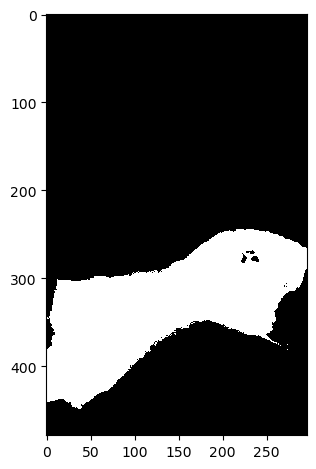

In [61]:
imshow(cart_mask_gap, cmap="gray")

In [198]:
print(length_gapCart, length_bone, dist_left, dist_right)
pct_closed = 1 - length_gapCart/(length_bone + dist_left + dist_right)
print(pct_closed)

0 207 6 6
1.0


In [199]:
print(length_gapCart2, length_bone, dist_left, dist_right)
pct_closed = 1 - length_gapCart2/(length_bone + dist_left + dist_right)
print(pct_closed)

0 207 6 6
1.0


In [212]:
##################################################
### batch calculation of all images 
##################################################

In [66]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/processed/ilastik_batch"
path_results = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/' \
        + 'downstream_ilastik' + '/'
outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)


/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/downstream_ilastik/


In [67]:
data = {"image": [], "bone_gap":[],  "left_cuttingPlan":[], "right_cuttingPlan":[], 
        "cartilage_boneGap":[],  "cartilage_boneGap_2":[], "cartilage_boneCutting":[],   "cartilage_boneCutting_2":[],  
         "pct_closure_1":[],  "pct_closure_2":[], "pct_closure_3":[], "pct_closure_4":[]
       }

df = pd.DataFrame(data)

In [68]:
df

,image,bone_gap,left_cuttingPlan,right_cuttingPlan,cartilage_boneGap,cartilage_boneGap_2,cartilage_boneCutting,cartilage_boneCutting_2,pct_closure_1,pct_closure_2,pct_closure_3,pct_closure_4


675907-LNP4-limb1-071025_Probabilities.tif (1920, 2560, 3)
0.05244755244755239 0.05069930069930073  0.027972027972028024  0.02622377622377625
675911-LNP3-limb2_Probabilities.tif (1920, 2560, 3)
1.0 1.0  1.0  1.0
675907-LNP4-limb1_Probabilities.tif (1920, 2560, 3)
0.07969639468690703 0.07779886148007586  0.06641366223908918  0.06451612903225812
675930-LNP3-limb2_Probabilities.tif (1920, 2560, 4)
0.20705882352941174 0.20470588235294118  0.14117647058823535  0.13882352941176468
675907-LNP4-limb2-071025_Probabilities.tif (1920, 2560, 3)
0.08163265306122447 0.07908163265306123  0.005102040816326481  0.0025510204081632404
676002-LNP2-limb1_Probabilities.tif (1920, 2560, 4)
0.24056603773584906 0.23899371069182385  0.24056603773584906  0.23899371069182385
675907-LNP4-limb2_Probabilities.tif (1920, 2560, 3)
0.09090909090909094 0.08939393939393936  0.08939393939393936  0.08333333333333337
675948-LNP2-limb1_Probabilities.tif (1920, 2560, 3)
0.18452380952380953 0.1830357142857143  0.18452380952380

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_55730/254697766.py:75: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 4, figsize=(24, 6))


0.1009523809523809 0.09333333333333338  0.1009523809523809  0.07428571428571429
675976-LNP4-limb2-290925a_Probabilities.tif (1920, 2560, 3)
0.32687651331719125 0.32445520581113807  0.32687651331719125  0.32445520581113807
675976-LNP4-limb2-290925_Probabilities.tif (1920, 2560, 3)
0.173697270471464 0.16377171215880892  0.141439205955335  0.13151364764267992
675976-LNP4-limb2_Probabilities.tif (1920, 2560, 3)
0.2898936170212766 0.27393617021276595  0.2898936170212766  0.27393617021276595
675982-LNP1-limb1_Probabilities.tif (1920, 2560, 3)
0.9615384615384616 0.9538461538461538  0.9641025641025641  0.8948717948717949
675982-LNP1-limb2_Probabilities.tif (1920, 2560, 3)
0.4528301886792453 0.45013477088948783  0.4528301886792453  0.45013477088948783
675995-LNP1-limb1_Probabilities.tif (1920, 2560, 3)
0.04179566563467496 0.04024767801857587  0.018575851393188847  0.017027863777089758
676002-LNP2-limb2_Probabilities.tif (1920, 2560, 3)
0.3191489361702128 0.31702127659574464  0.3191489361702128 

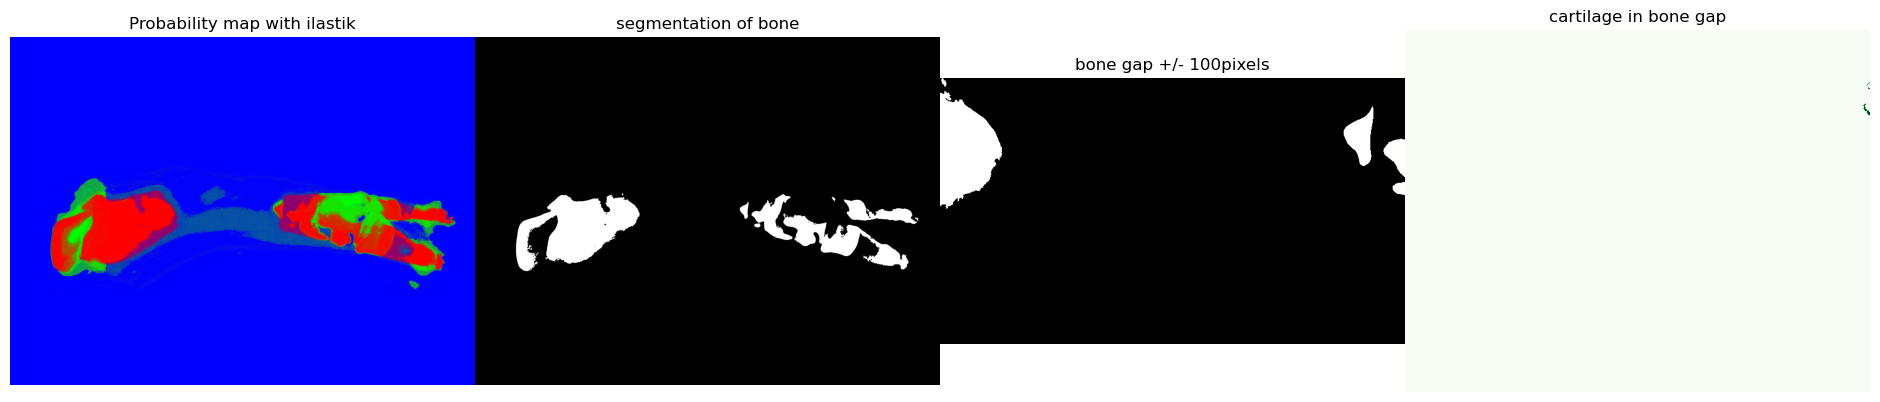

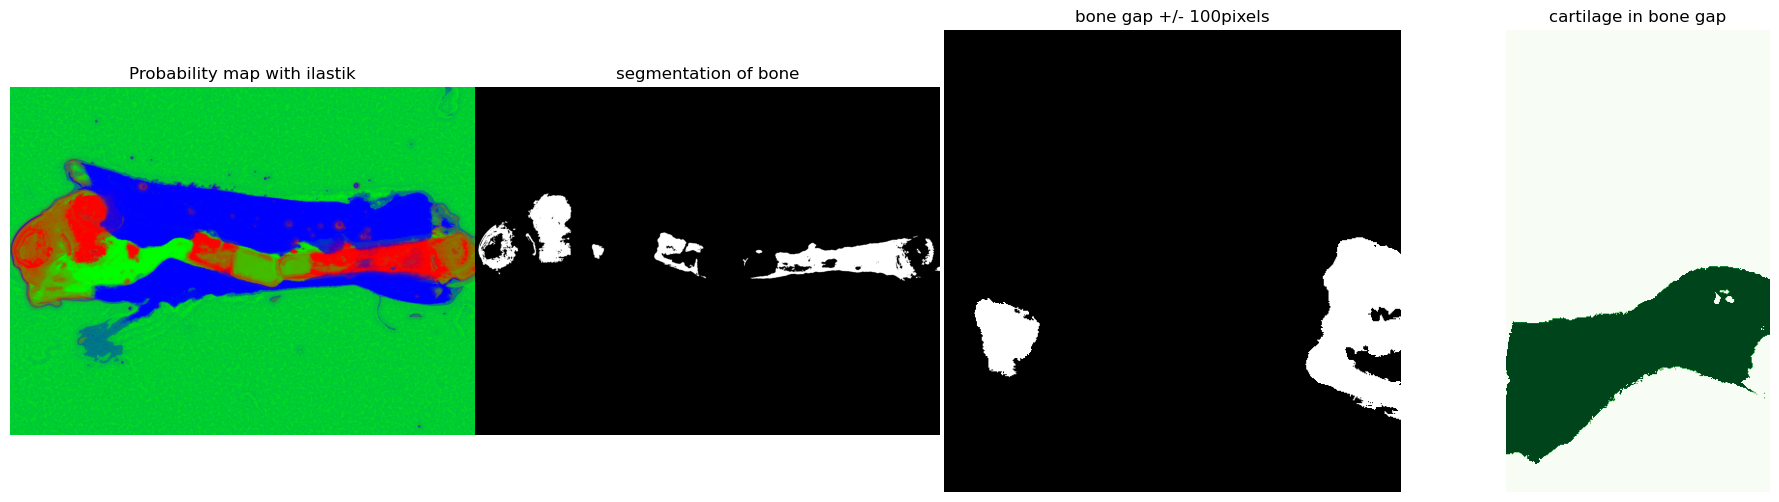

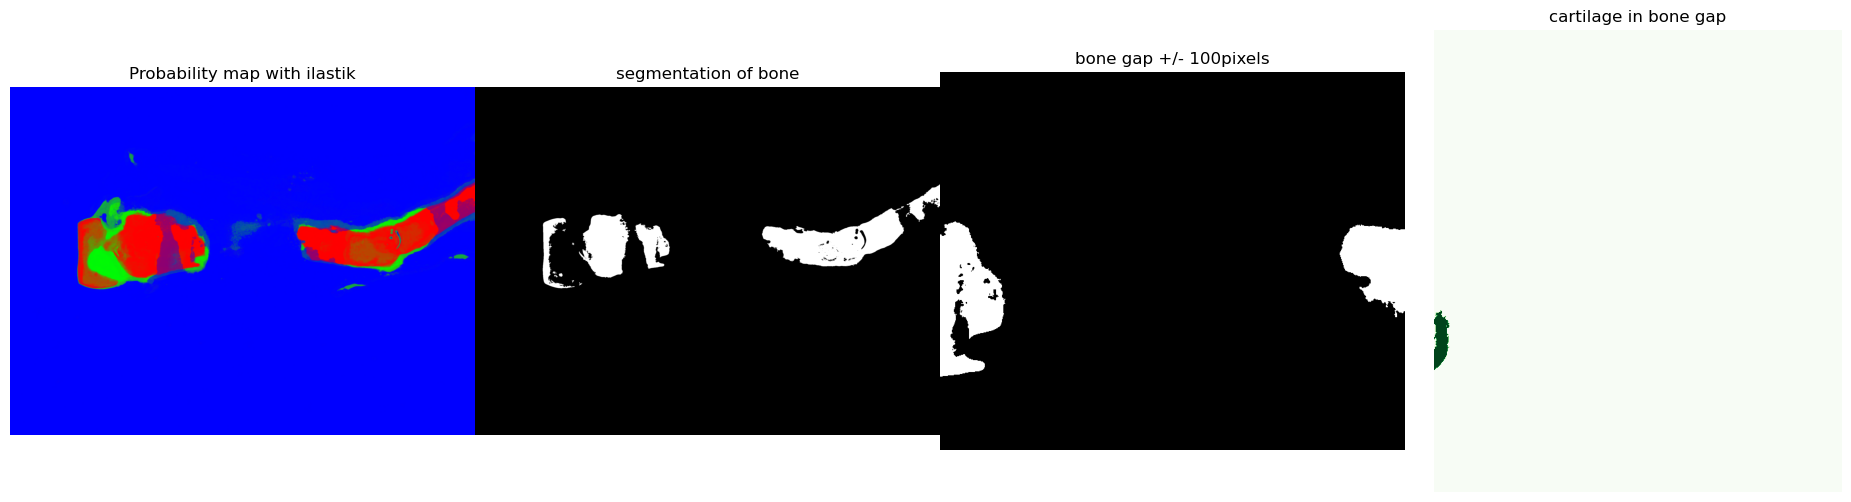

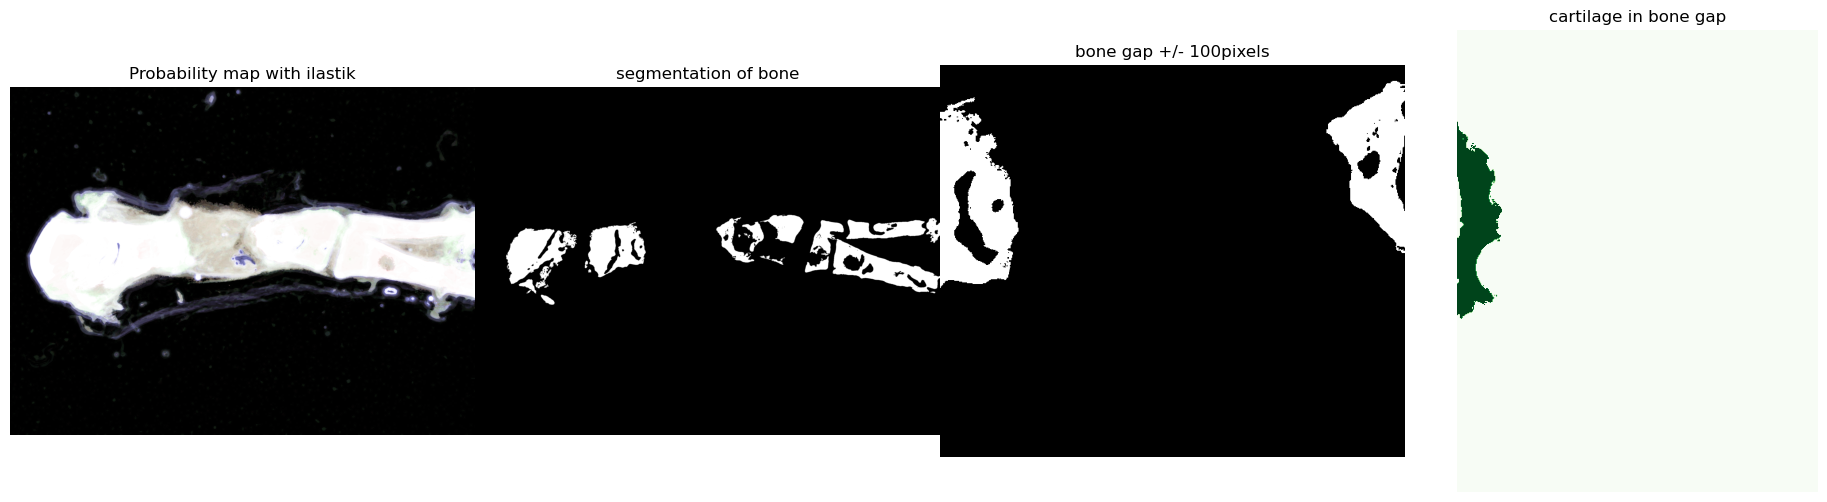

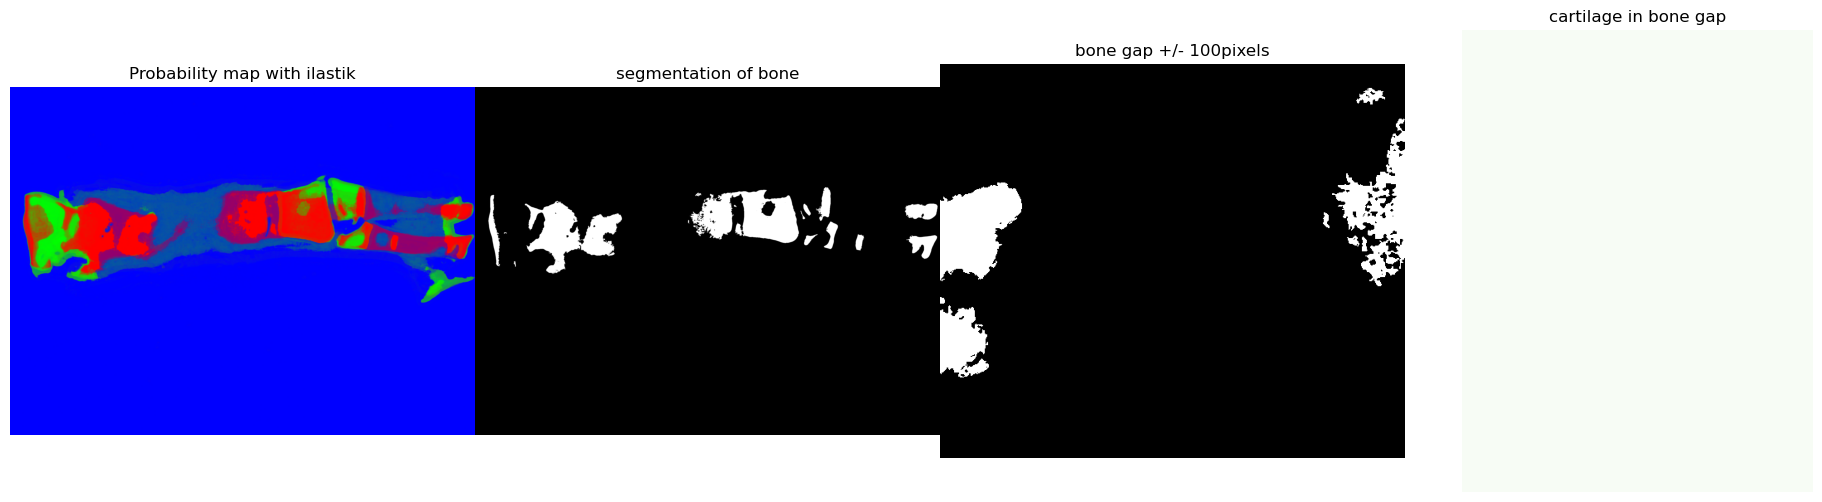

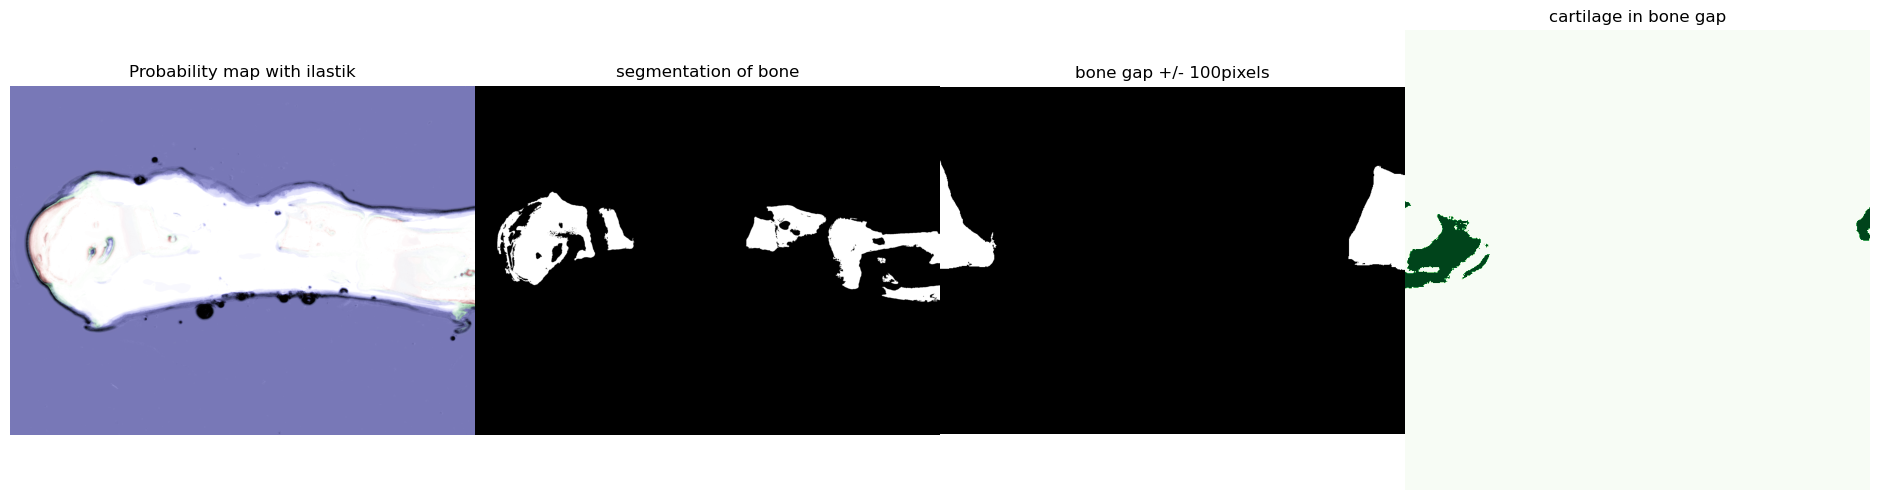

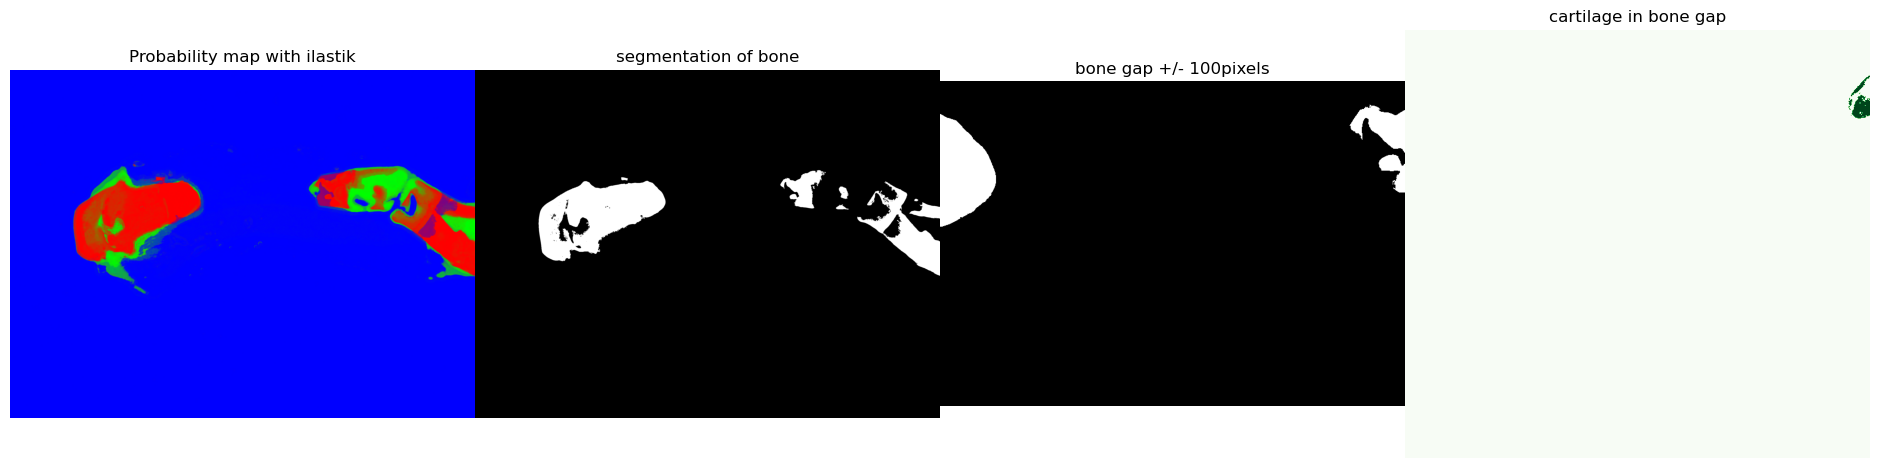

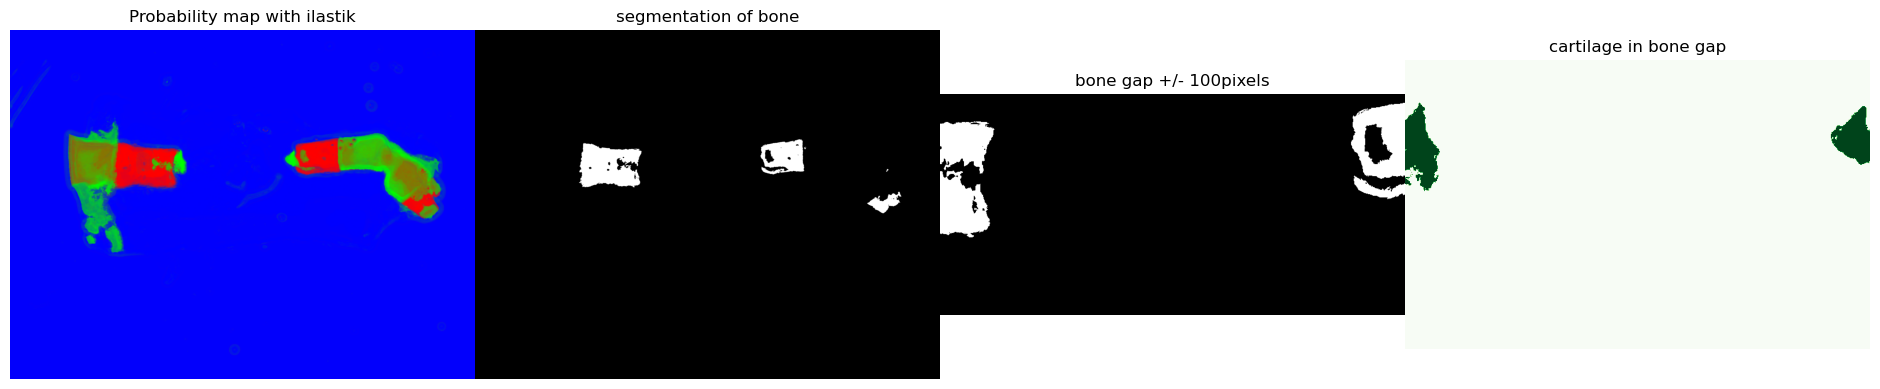

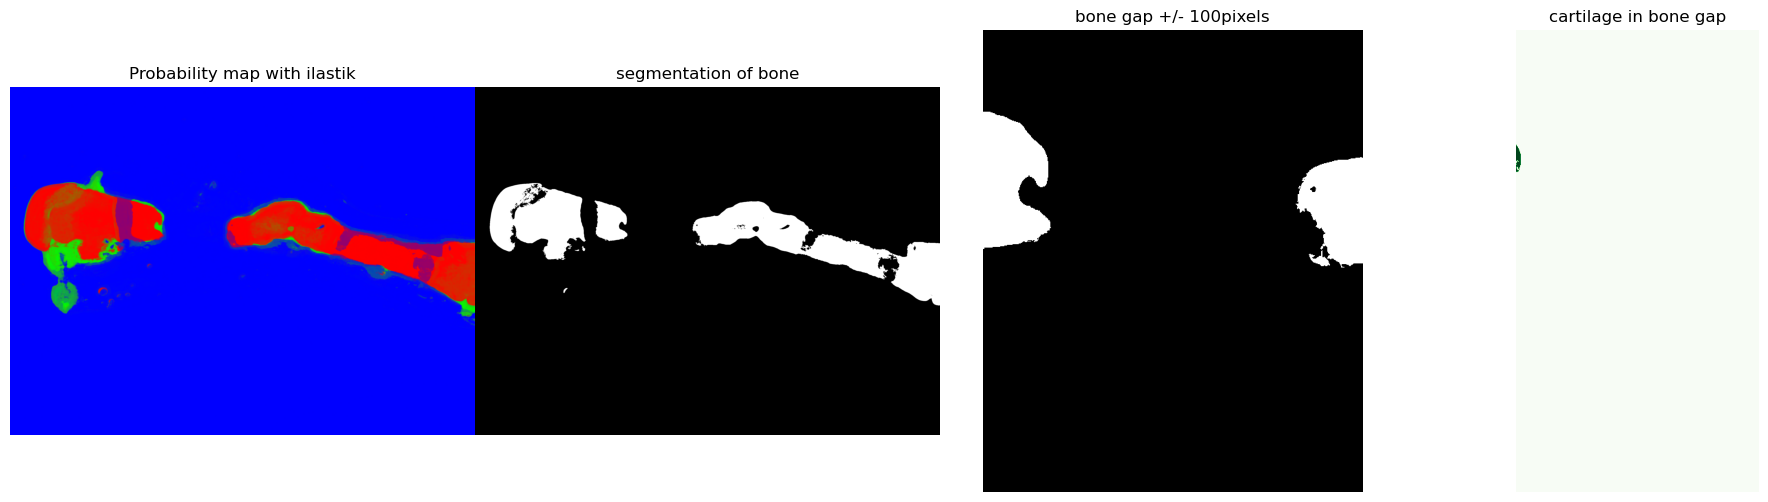

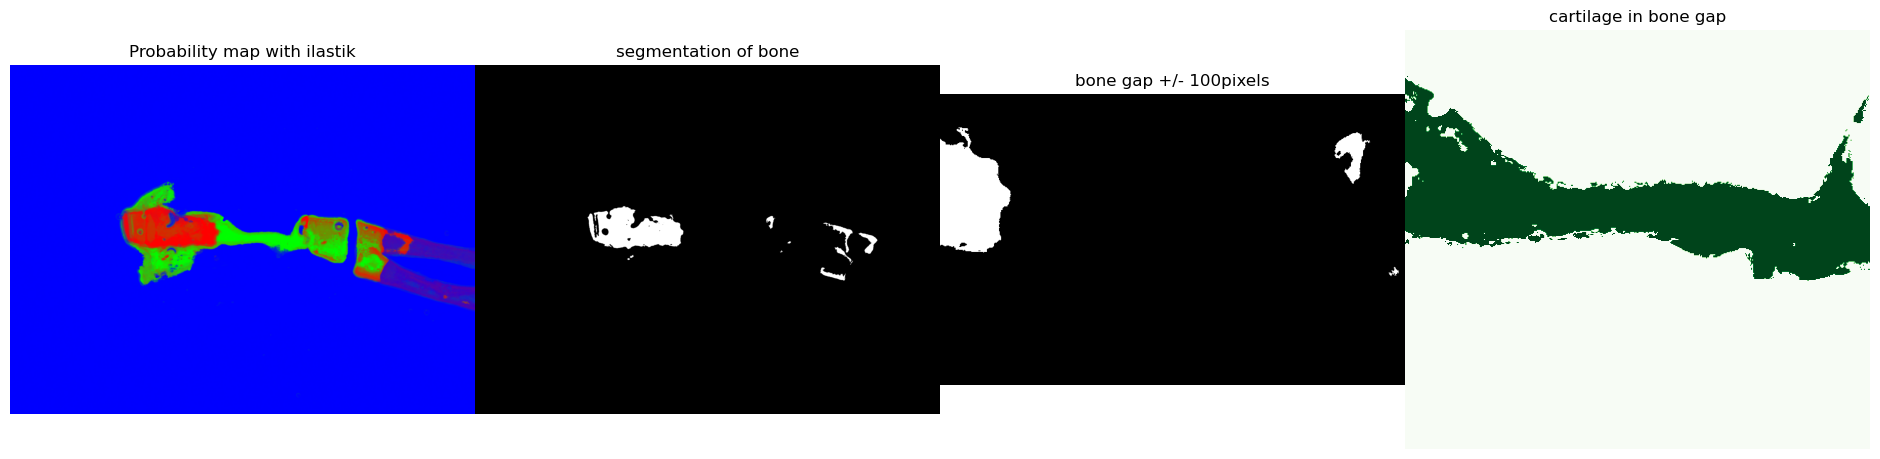

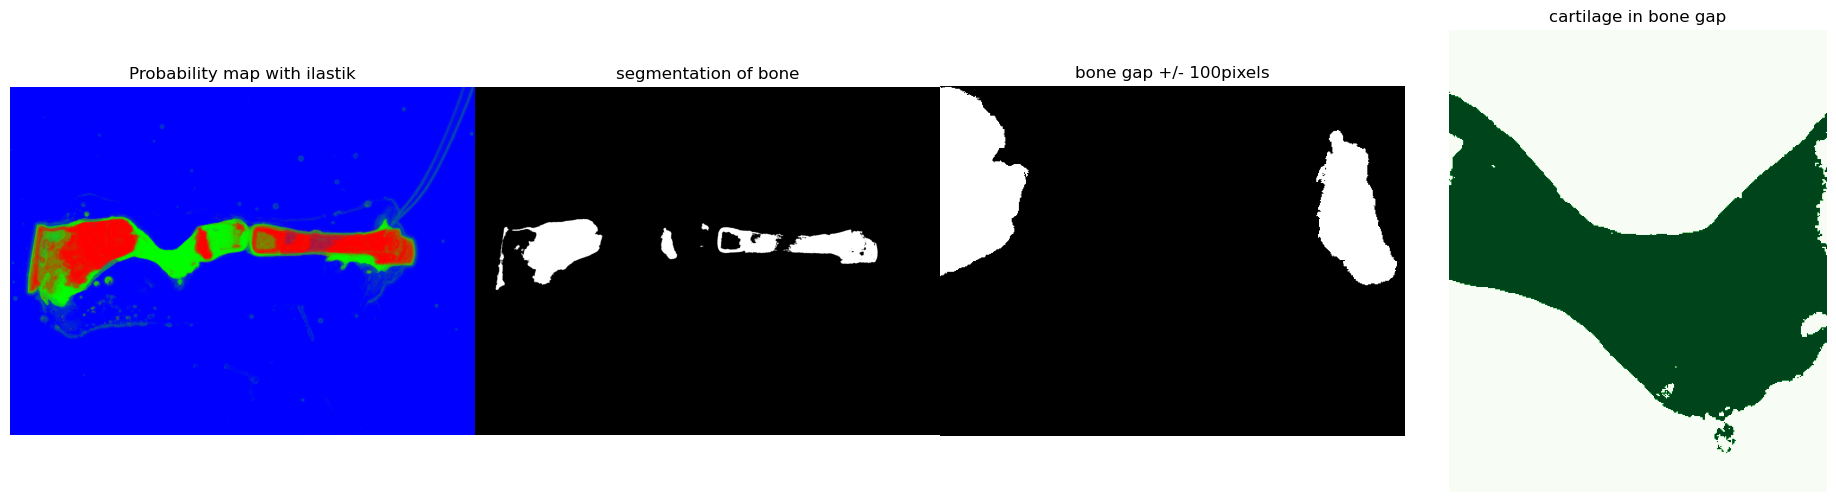

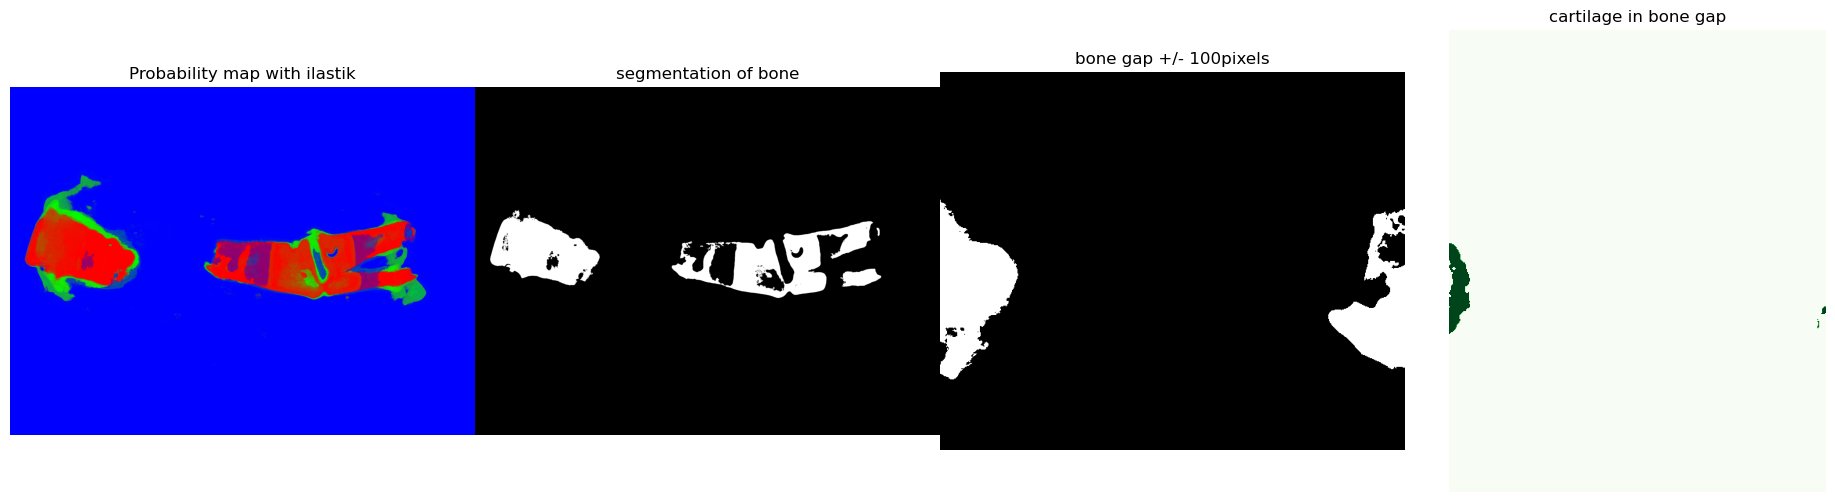

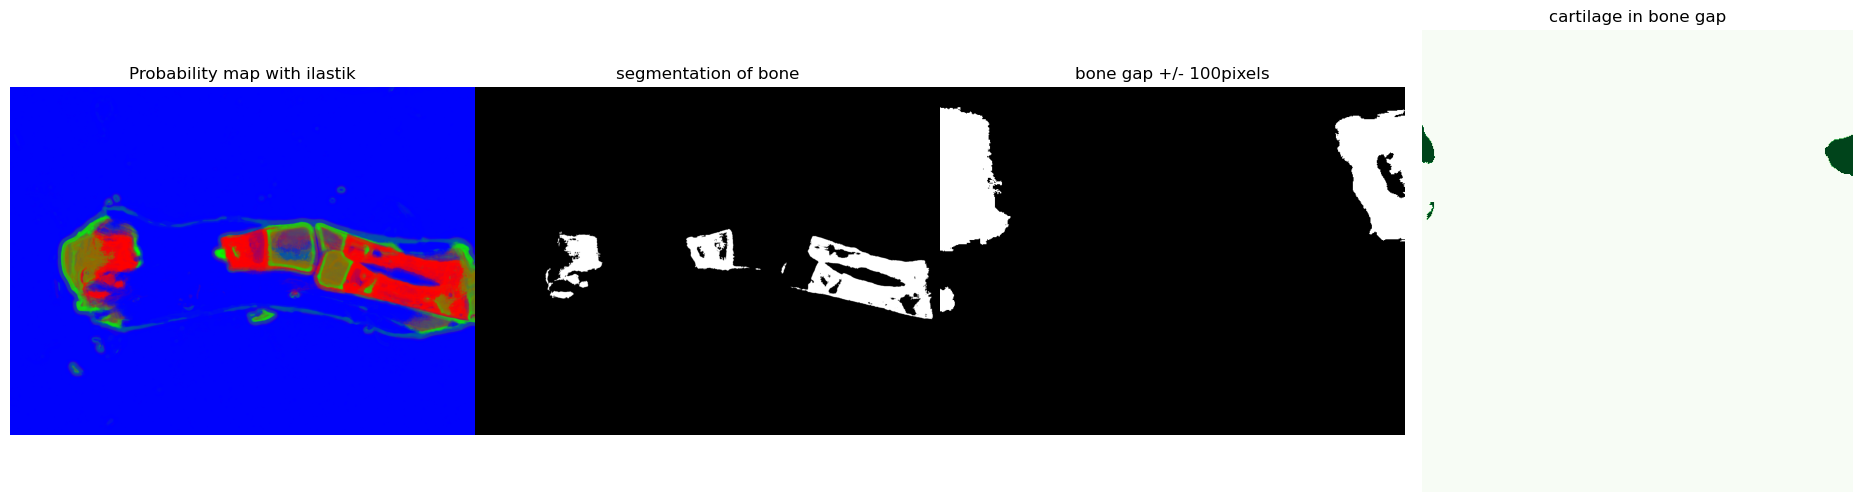

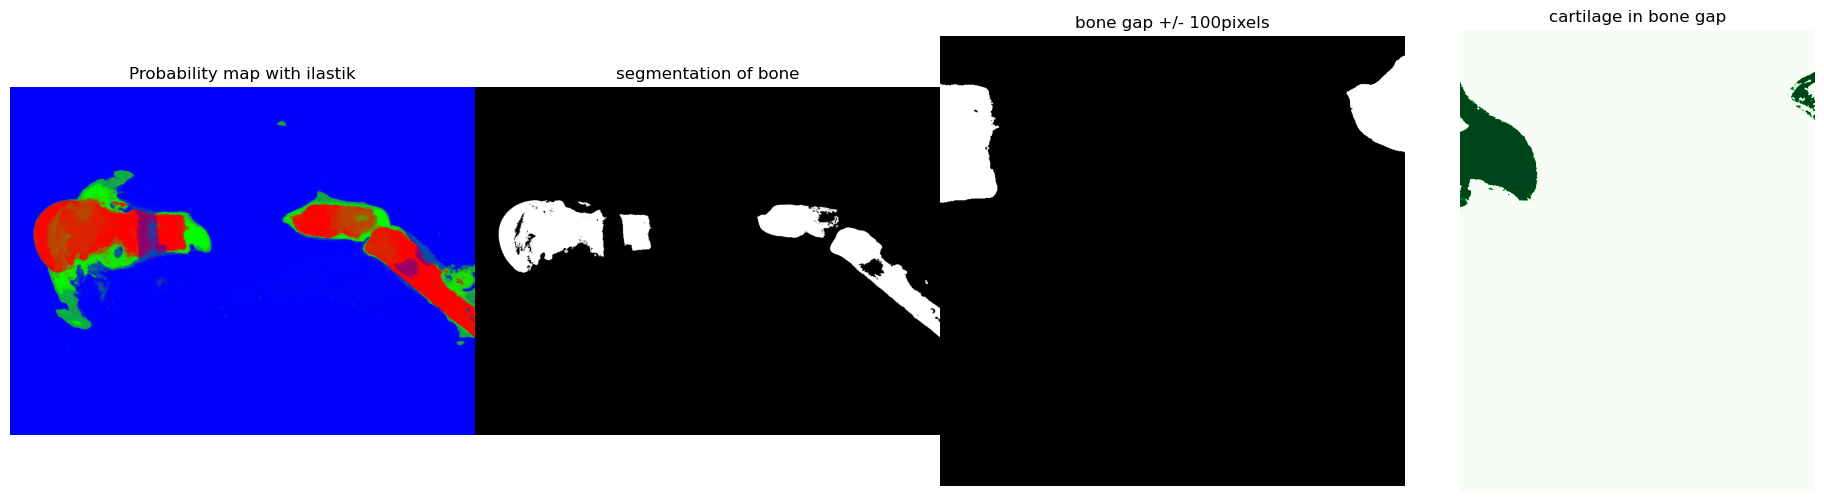

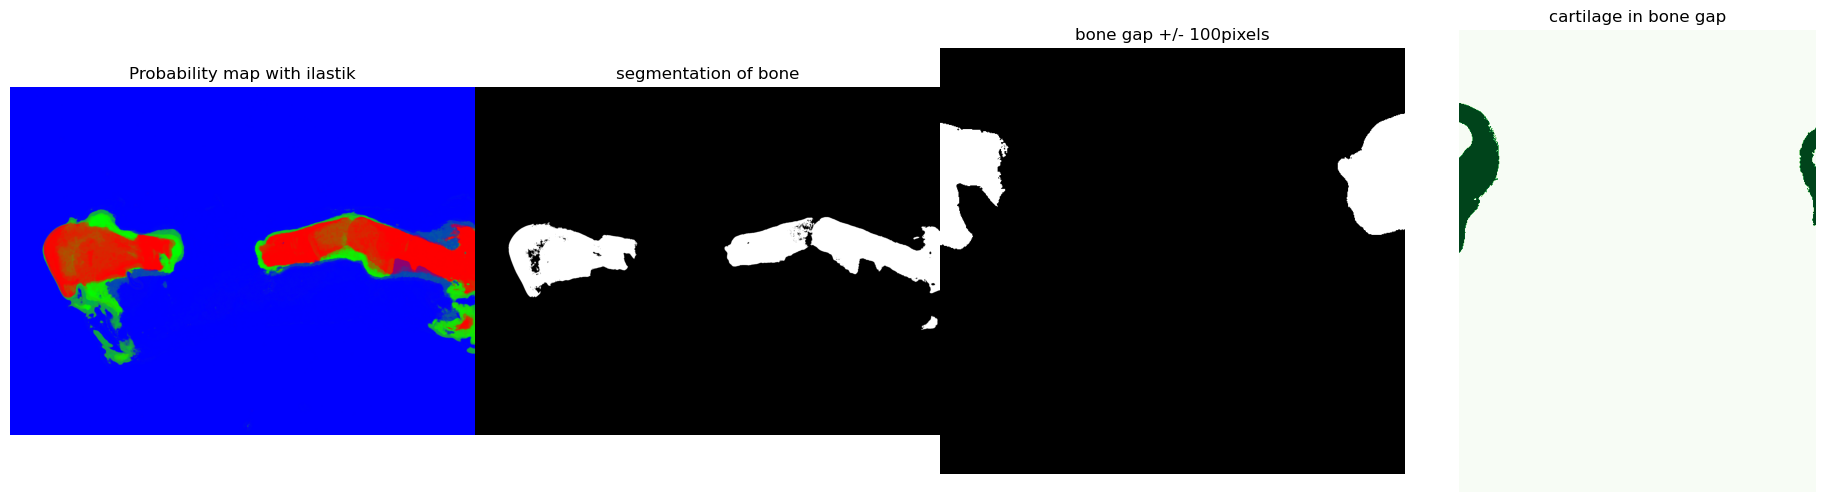

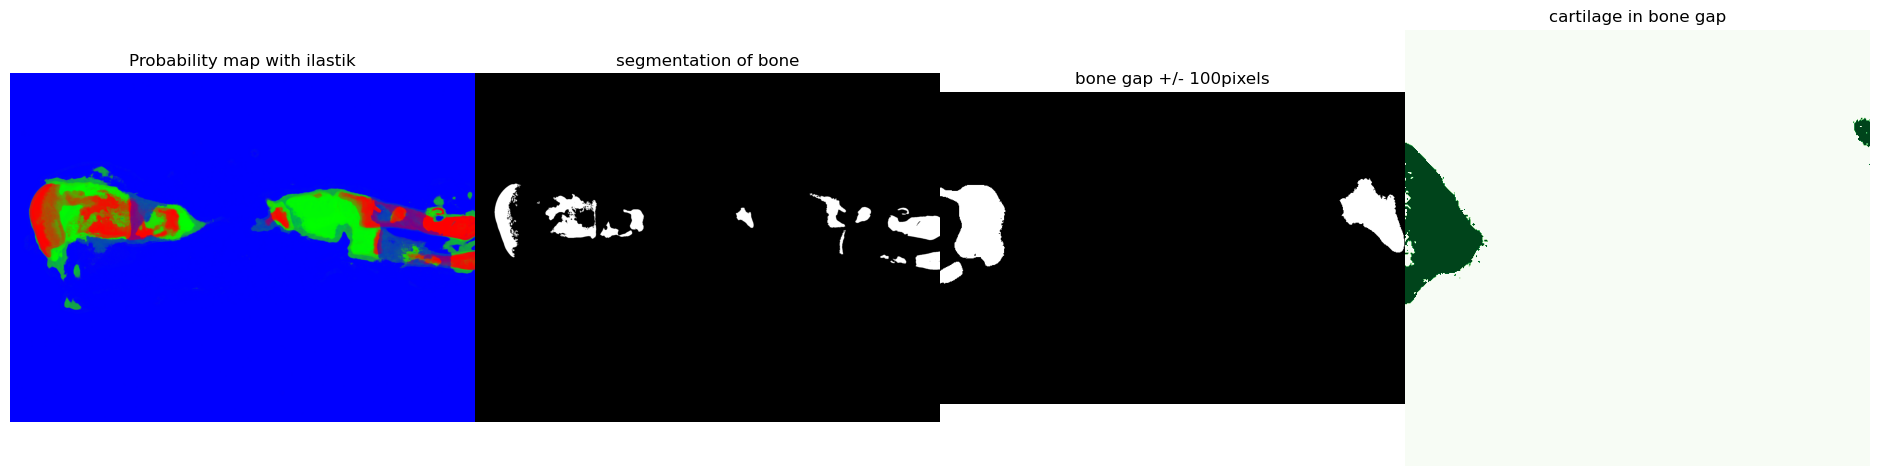

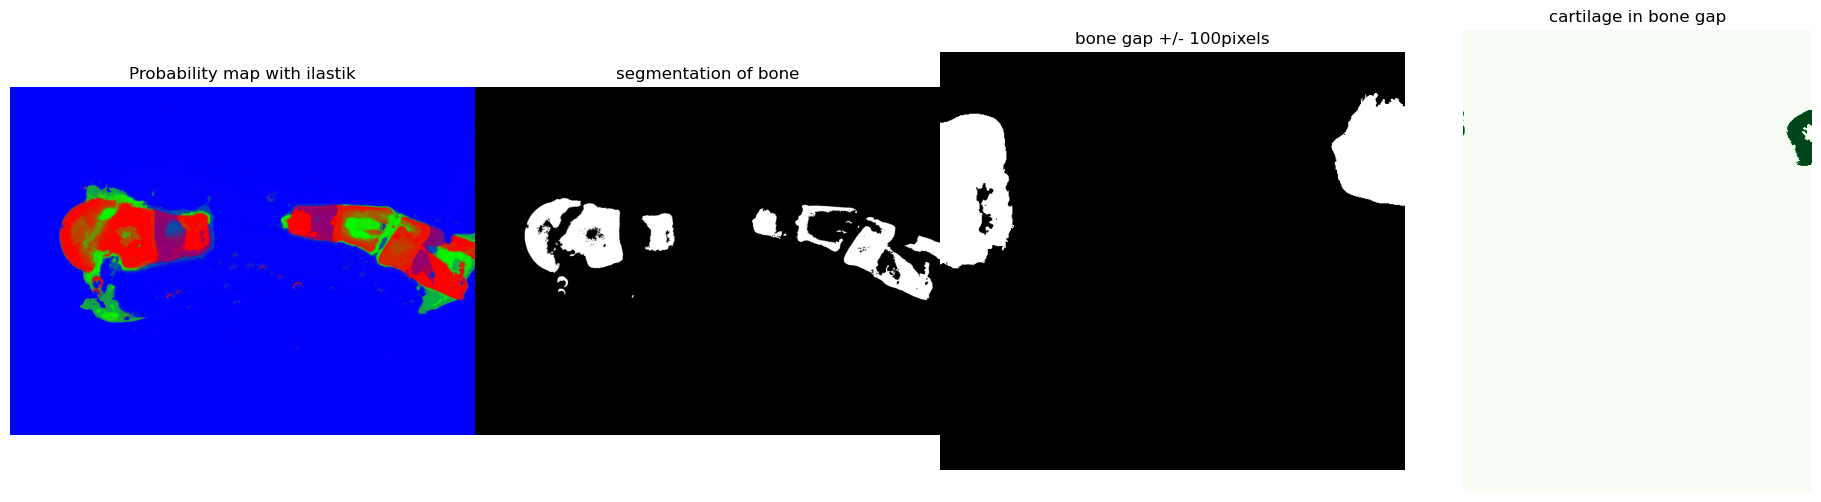

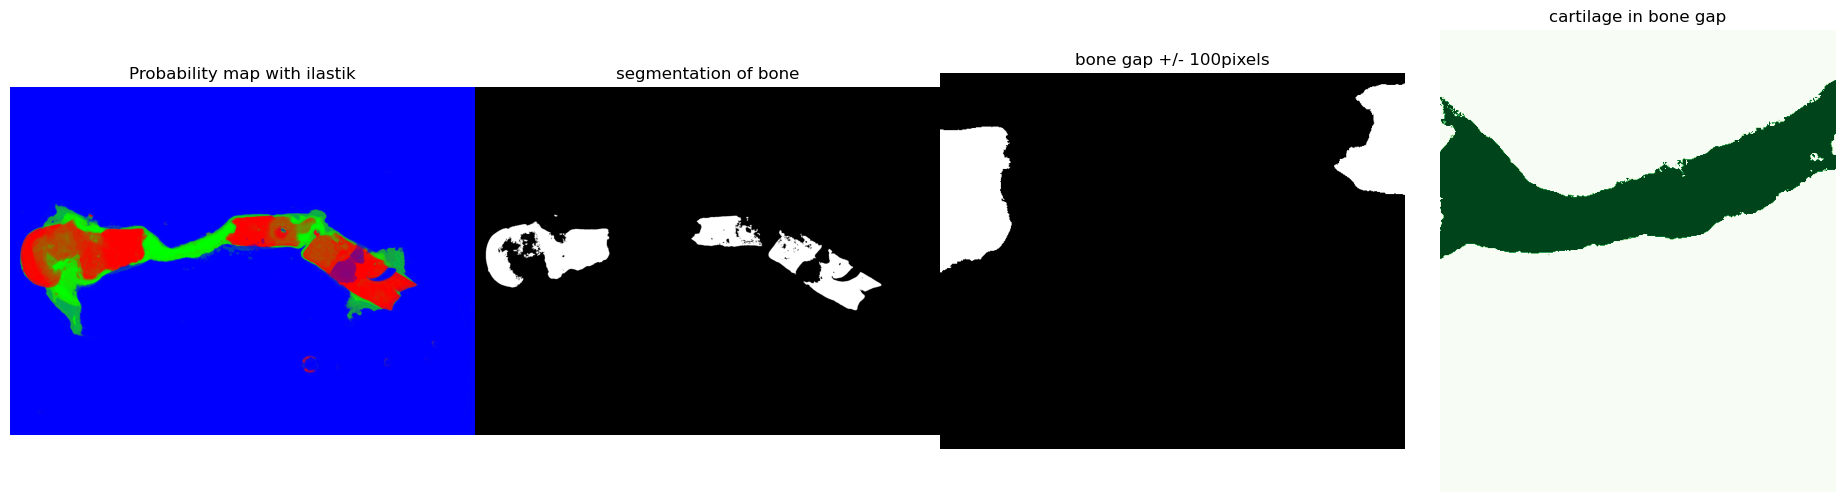

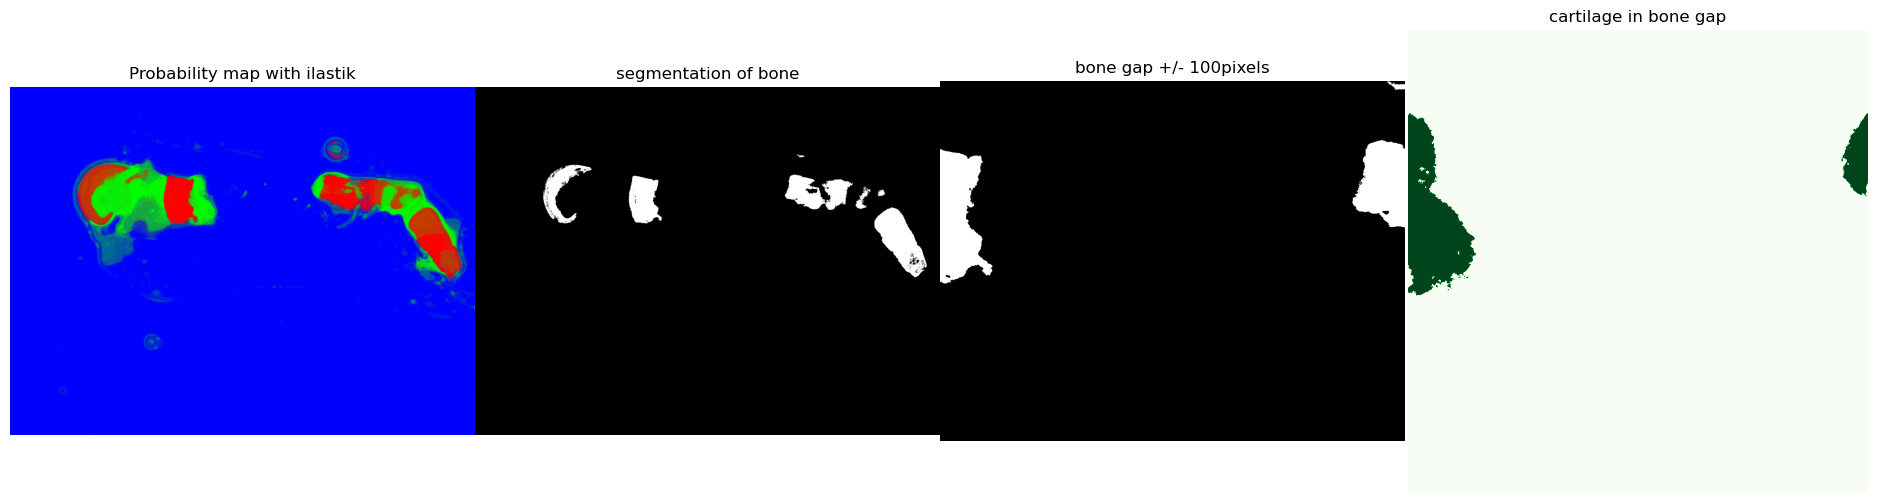

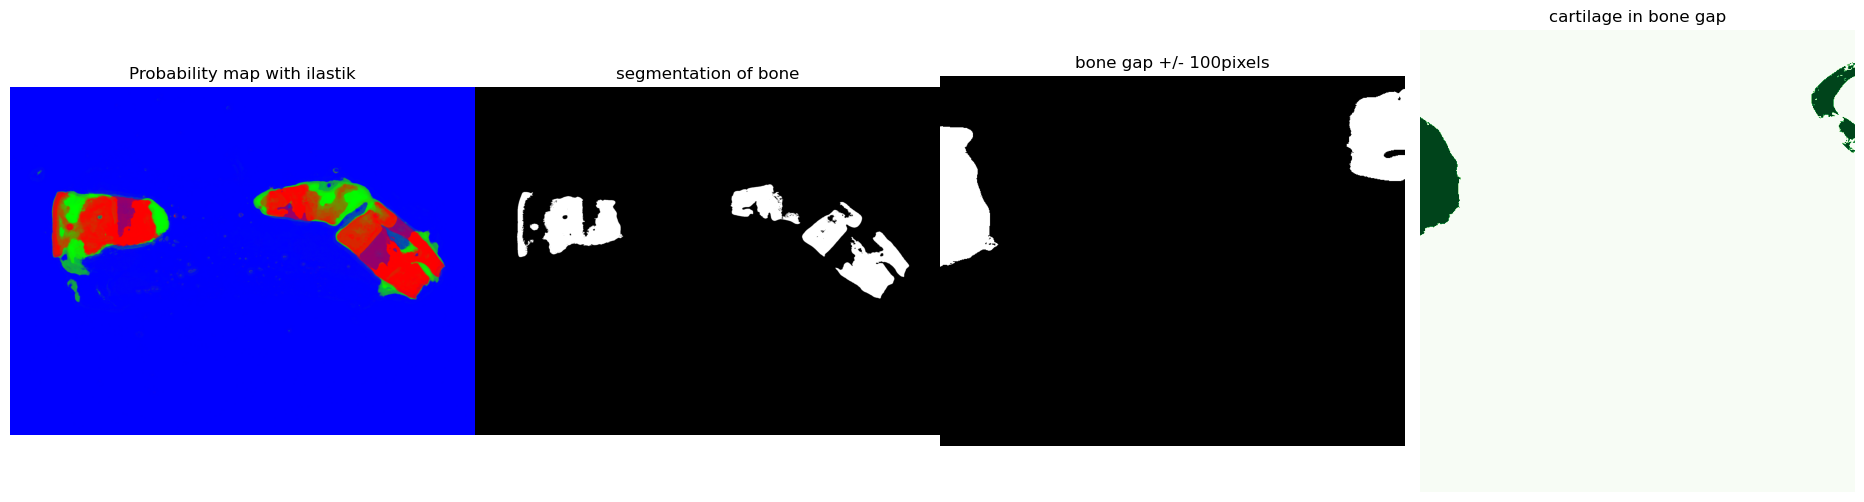

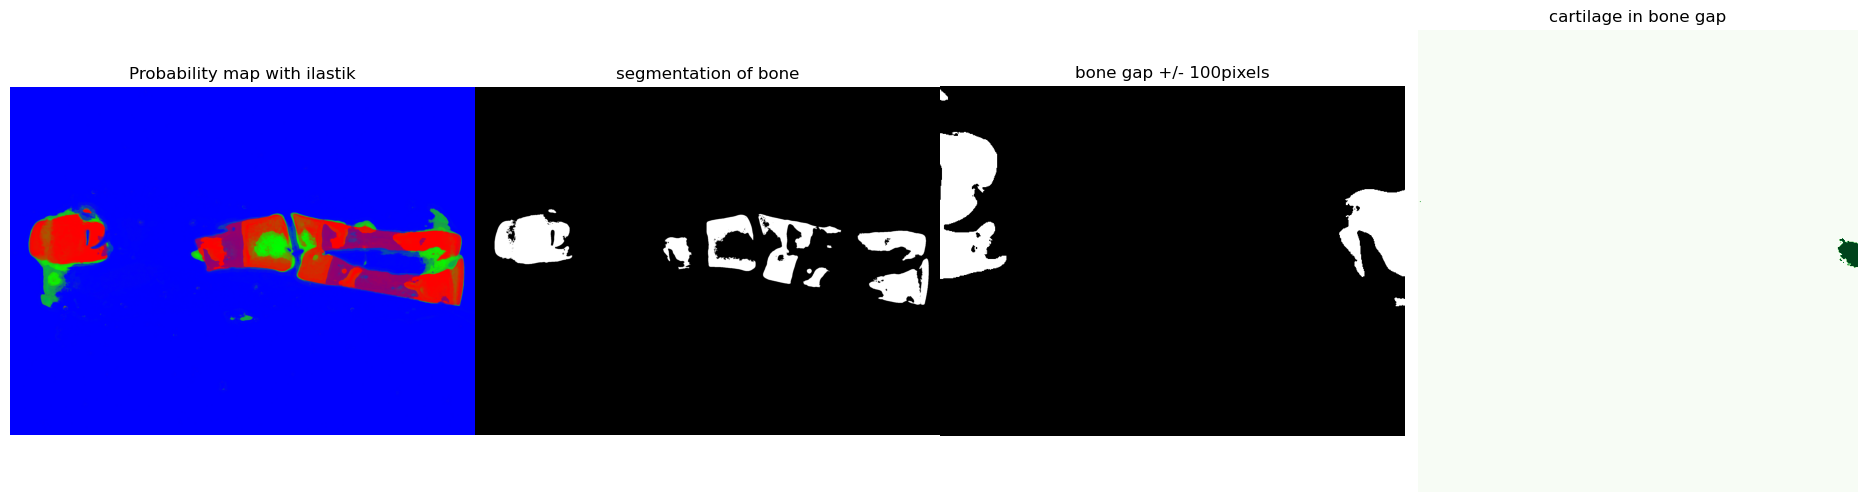

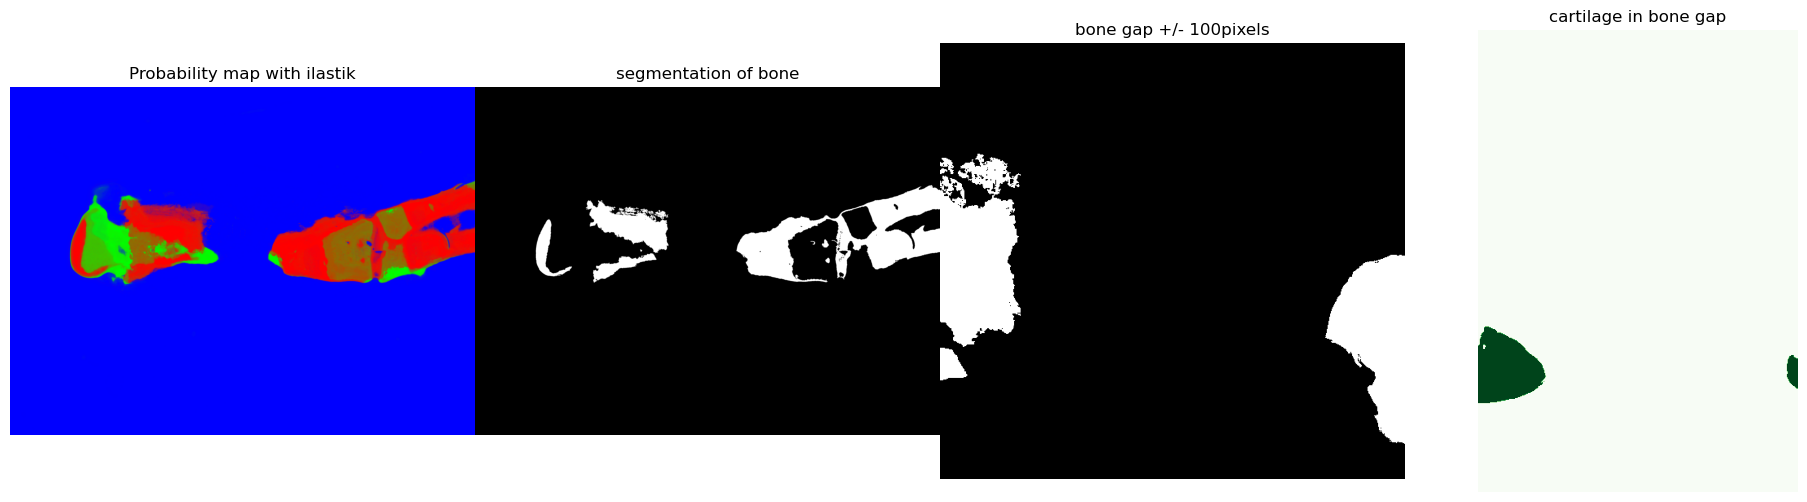

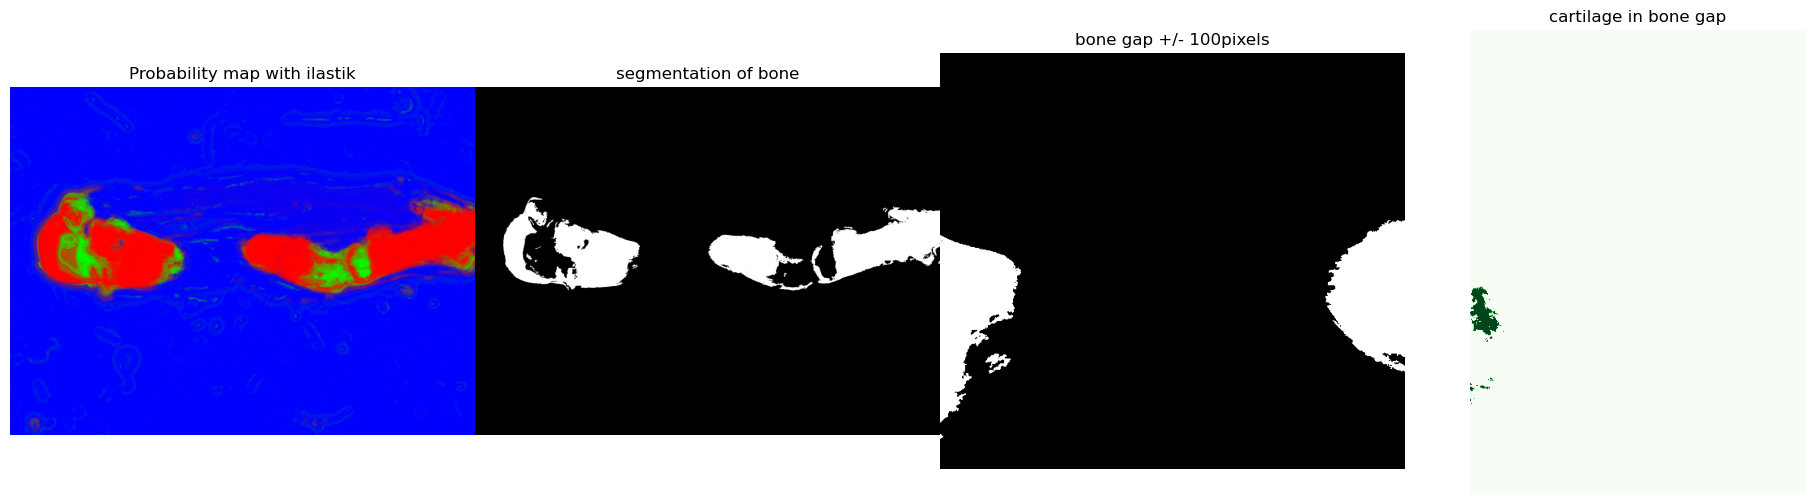

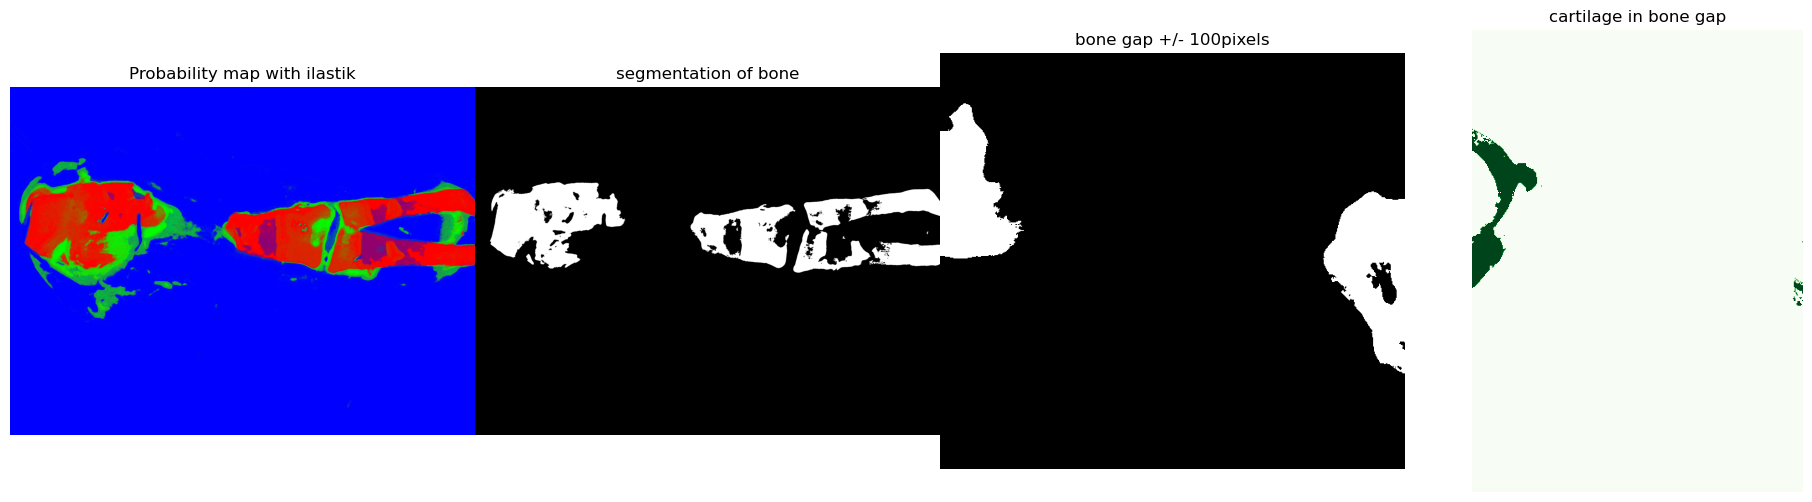

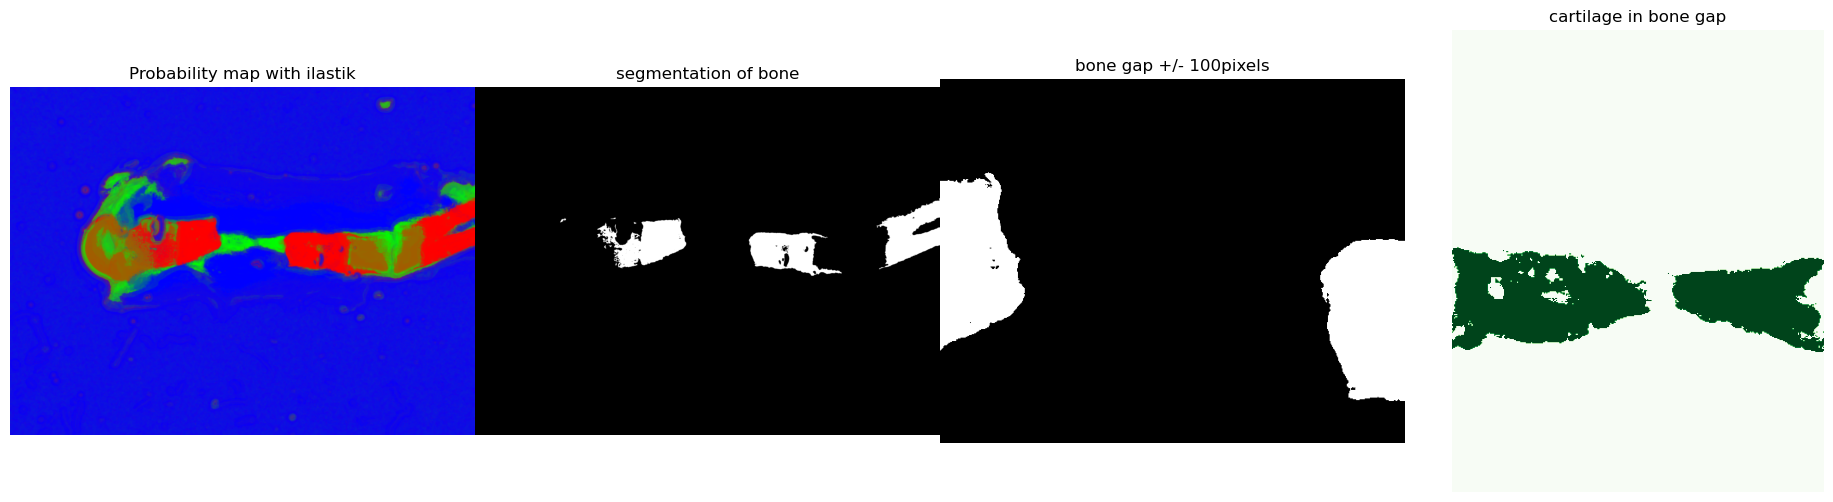

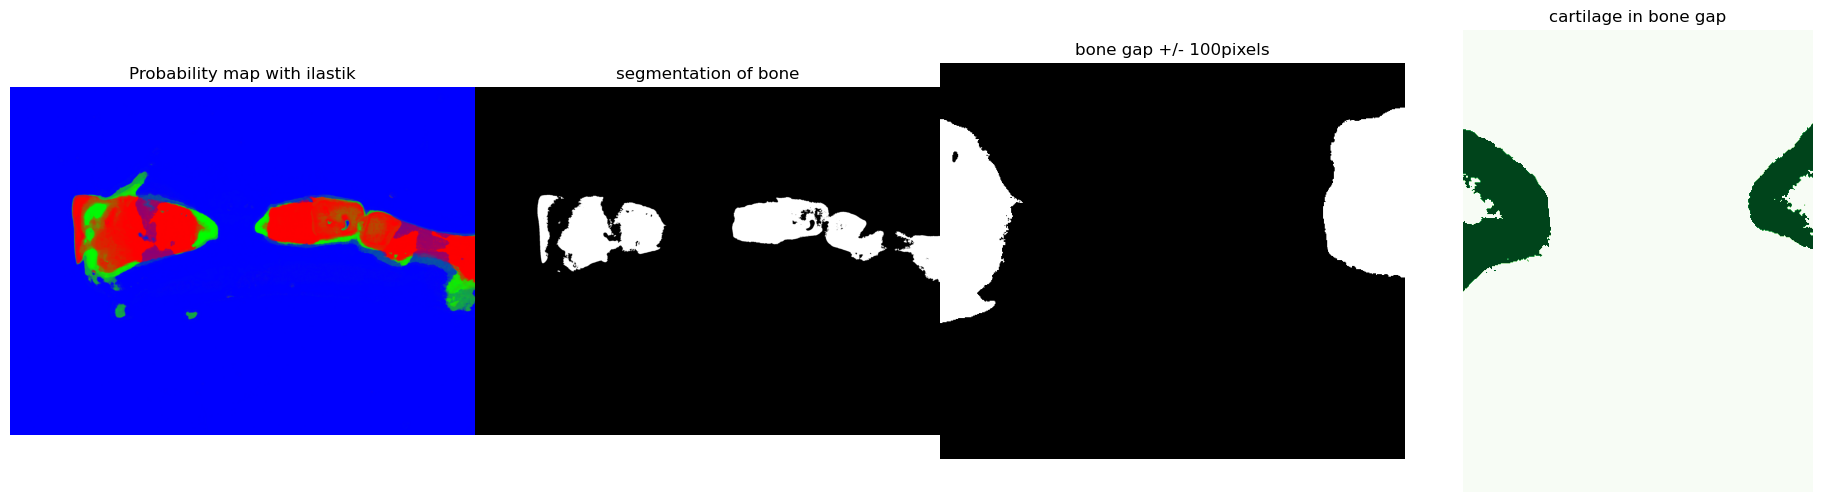

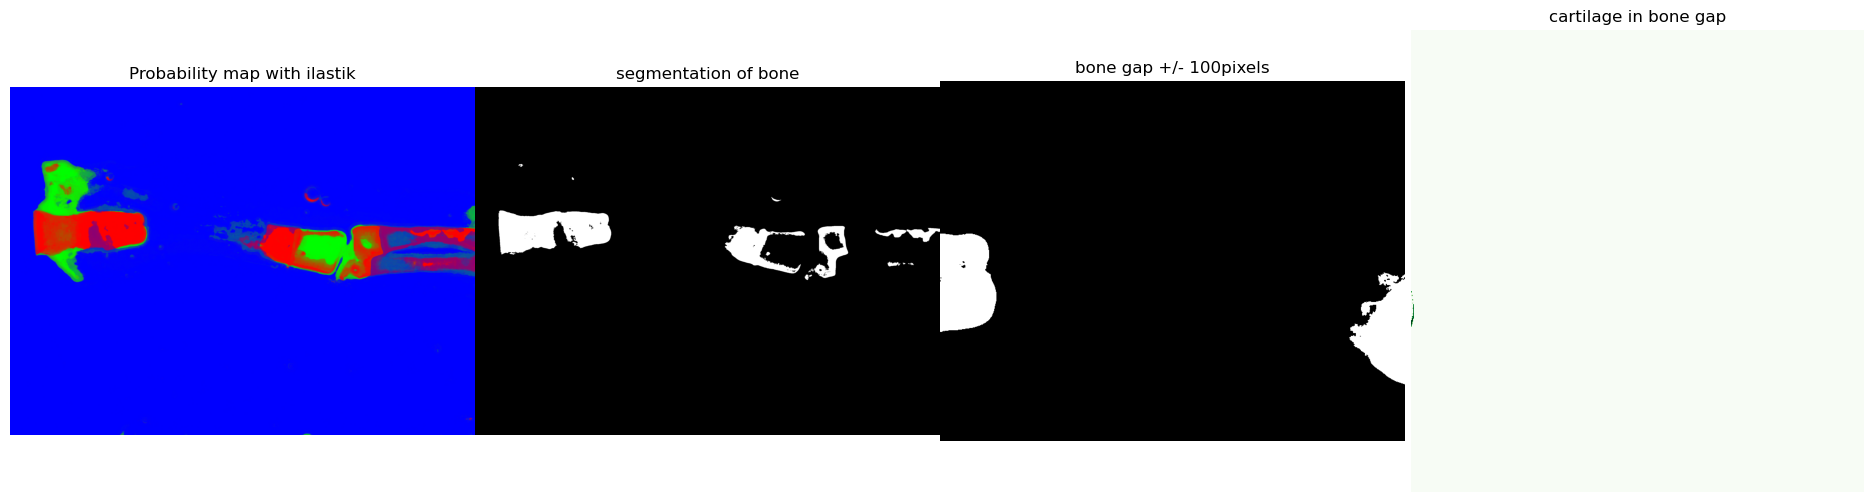

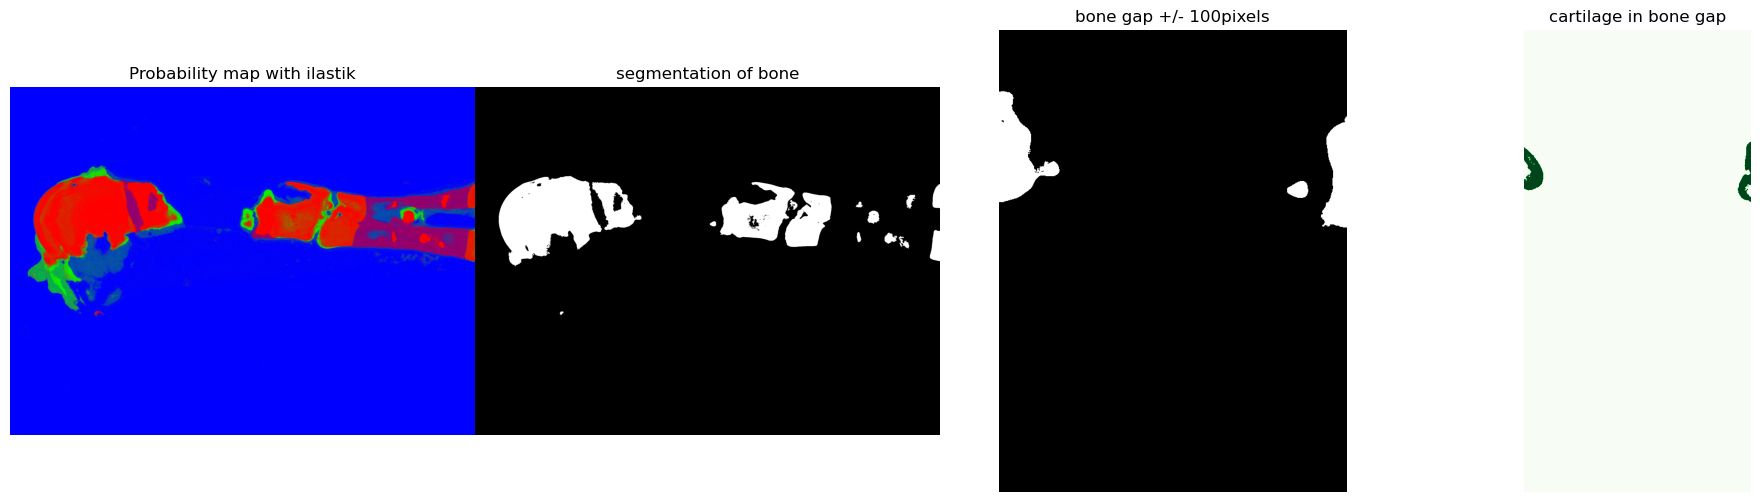

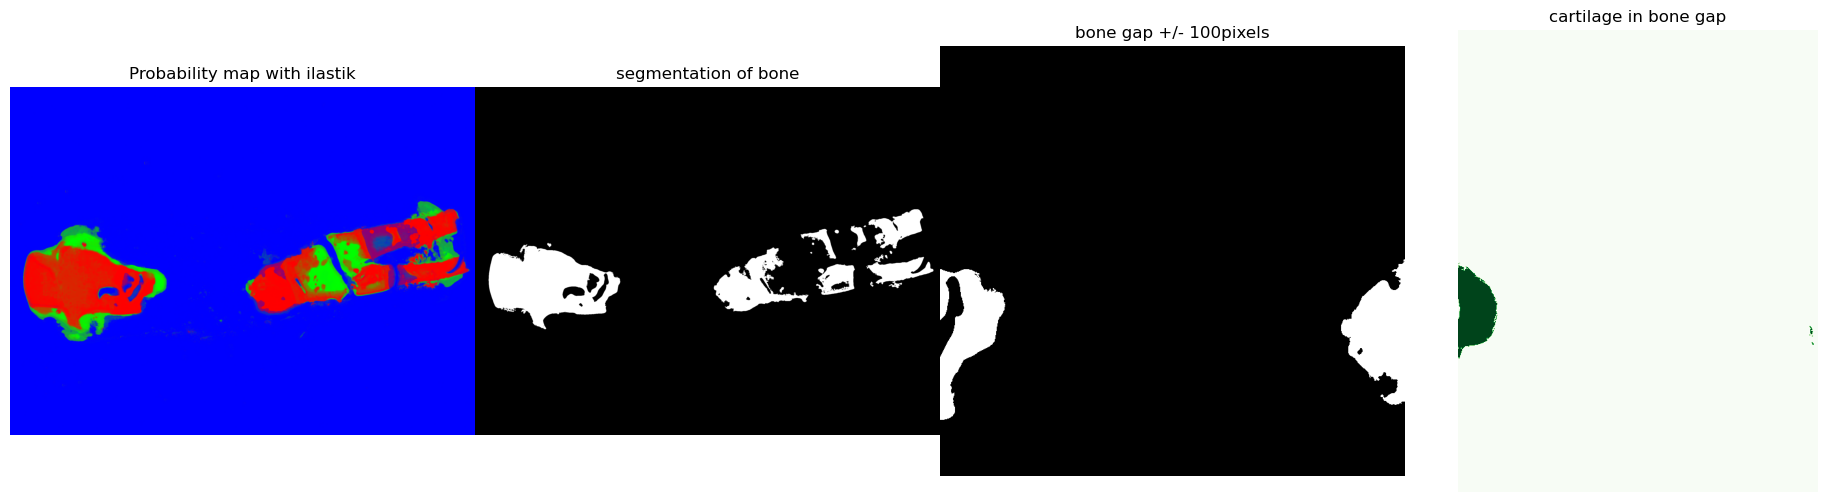

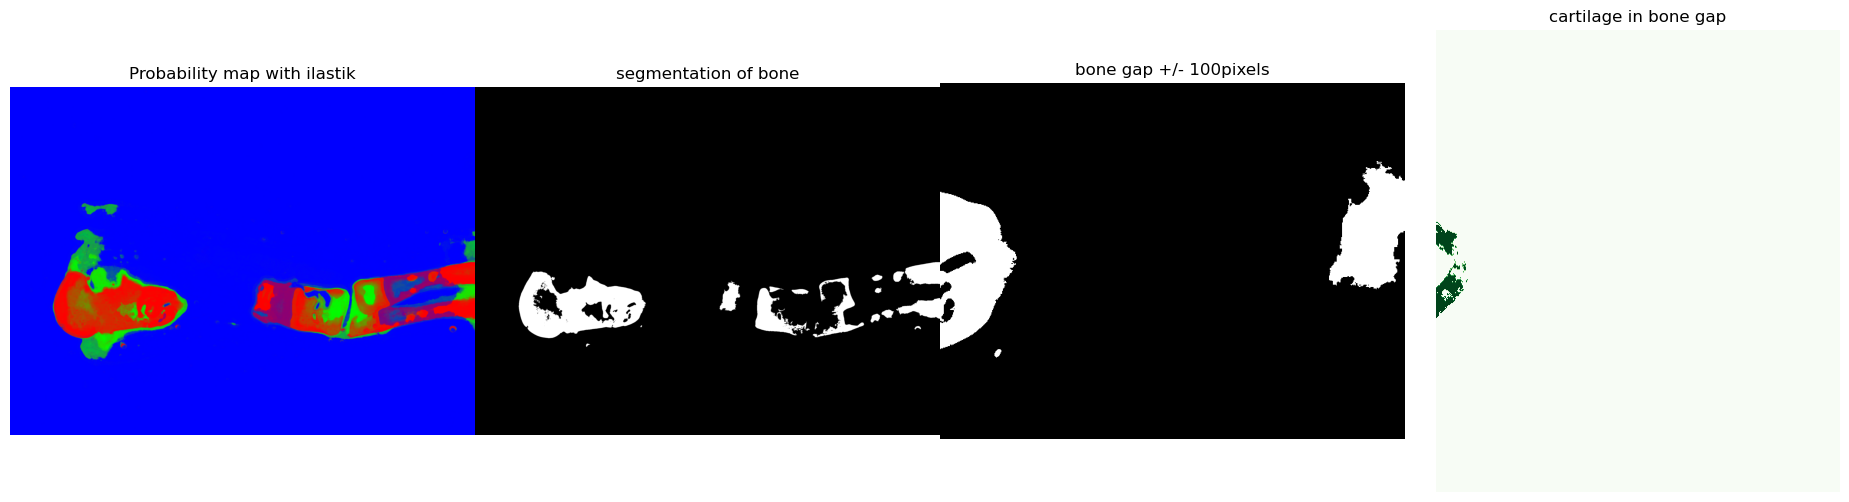

In [69]:
for nm in os.listdir(inputDir):
    #if "C4_CystMask.tiff" in nm:
    if "_Probabilities.tif" in nm:
        #print(nm)
        #fileName = nm.replace('_C4_CystMask.tiff','')
        fileName = nm.replace('_Probabilities.tif','')
        
        img_prob = imread(os.path.join(inputDir, nm))
        
        print(nm, img_prob.shape)
        
        # define masks for bone and cartilage
        bone_mask = img_prob[:, :, 0] > 0.7
        cart_mask = img_prob[:, :, 1] > 0.8
        
        bone_mask = morphology.remove_small_objects(bone_mask, min_size=64)
        
        ## cropping the image for the segmentation
        rowsum = bone_mask.sum(axis=1);
        idx_row = np.where(rowsum > 0)
        colsum = bone_mask.sum(axis=0);
        idx_col = np.where(colsum > 0)
        
        bone_mask_cropped = bone_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
        cart_mask_cropped = cart_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
        
        ## detect the bone gaps and gap border 
        colsum = bone_mask_cropped.sum(axis=0);
        idx_col = np.where(colsum == 0)
        #colsum2 = cart_mask_cropped.sum(axis = 0)
        gap_idx = find_max_gap(idx_col[0])
        length_bone = len(gap_idx)
        
        ## zoom in the gap region 
        bone_len = 100
        if np.min(gap_idx) < bone_len:
            bone_len = np.min(gap_idx)
            
        bone_mask_gap = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.max(gap_idx) + bone_len)]
        
        from scipy.signal import argrelextrema
        pct_cutPlan = 1/3
        
        ## left bone cutting plane 
        bone_left = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.min(gap_idx))]
        colsum_left = bone_left.sum(axis=0)
        colsum_left = colsum_left[::-1]
        #print(colsum_left[0:99])
        diff = abs(colsum_left - np.max(colsum_left) * pct_cutPlan)

        dist_left = argrelextrema(diff, np.less)[0][0]
        #print(dist_left)
        
        ## right bone cutting plane
        bone_right = bone_mask_cropped[:, (np.max(gap_idx)):(np.max(gap_idx) + bone_len)]
        colsum_right = bone_right.sum(axis=0)
        #colsum_right = colsum_right[::-1]
        #print(colsum_right)
        diff_right = abs(colsum_right - np.max(colsum_right) * pct_cutPlan)
        #print(diff.argmin(axis=0))
        dist_right = argrelextrema(diff_right, np.less)[0][0]
        
        #print(dist_right)
        
        ## measure the closure by cartilage within only the bone gap
        cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
        #cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
        colsum_cart = cart_mask_gap.sum(axis=0);
        idx_col_cart = np.where(colsum_cart == 0)
        gap_idx_cart = find_max_gap(idx_col_cart[0])
        length_gapCart = len(gap_idx_cart)
        length_gapCart1 = len(idx_col_cart[0])
        
         # Plot
        fig, ax = plt.subplots(1, 4, figsize=(24, 6))
        fig.subplots_adjust(wspace=0)

        ax[0].set_title("Probability map with ilastik")
        ax[0].imshow(img_prob)
        ax[0].set_axis_off()
        ax[1].set_title("segmentation of bone")
        ax[1].imshow(bone_mask, cmap='gray')
        ax[1].set_axis_off()
        ax[2].set_title("bone gap +/- 100pixels")
        ax[2].imshow(bone_mask_gap, cmap='gray')
        ax[2].set_axis_off()

        ax[3].set_title("cartilage in bone gap")
        ax[3].imshow(cart_mask_gap, cmap='Greens')
        ax[3].set_axis_off()
        
        fig.savefig(os.path.join(outDir, str(fileName + "_segmentation_measure.tif")))
        #imsave(, fig)
        #imsave(os.path.join(outDir, str(fileName + "mask_newCartilage.tif")), cart_mask)
        
        
        ## measure the closure by cartilage within bone gaps + left and right cutting plan
        cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)-dist_left):(np.max(gap_idx) + dist_right)]
        colsum_cart = cart_mask_gap.sum(axis=0);
        idx_col_cart = np.where(colsum_cart == 0)
        gap_idx_cart2 = find_max_gap(idx_col_cart[0])
        length_gapCart2 = len(gap_idx_cart2)
        length_gapCart3 = len(idx_col_cart[0])
        
        #print(length_gapCart, length_bone, dist_left, dist_right)
        pct_closed = 1 - length_gapCart/(length_bone + dist_left + dist_right)
        #print(pct_closed)
        
        pct_closed1 = 1 - length_gapCart1/(length_bone + dist_left + dist_right)
        #print(pct_closed1)
        
        #print(length_gapCart2, length_bone, dist_left, dist_right)
        pct_closed2 = 1 - length_gapCart2/(length_bone + dist_left + dist_right)
        #print(pct_closed2)
        
        pct_closed3 = 1 - length_gapCart3/(length_bone + dist_left + dist_right)
        print(str(pct_closed) + ' ' + str(pct_closed1) + '  ' + str(pct_closed2) + '  ' +  str(pct_closed3))
        
        
        df.loc[len(df)] = [fileName, length_bone, dist_left, dist_right, length_gapCart, length_gapCart1, length_gapCart2, length_gapCart3, pct_closed, pct_closed1, pct_closed2, pct_closed3 ]
        

In [70]:
df.to_csv(os.path.join(outDir, "ilastik_segmentation_pct_closure.csv"), index=True, header=True)

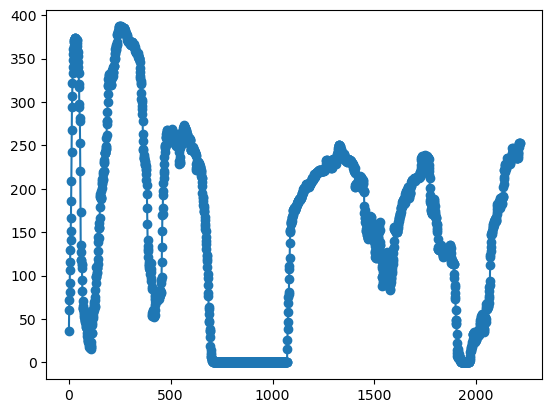

In [96]:
indices = np.arange(len(colsum))
plt.plot(indices, colsum, marker = 'o')

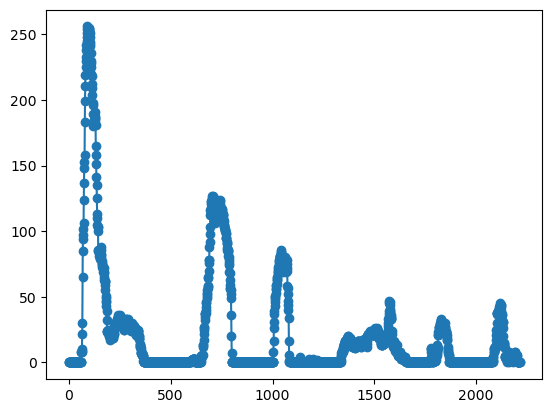

In [97]:
indices2 = np.arange(len(colsum2))
plt.plot(indices2, colsum2, marker = 'o')

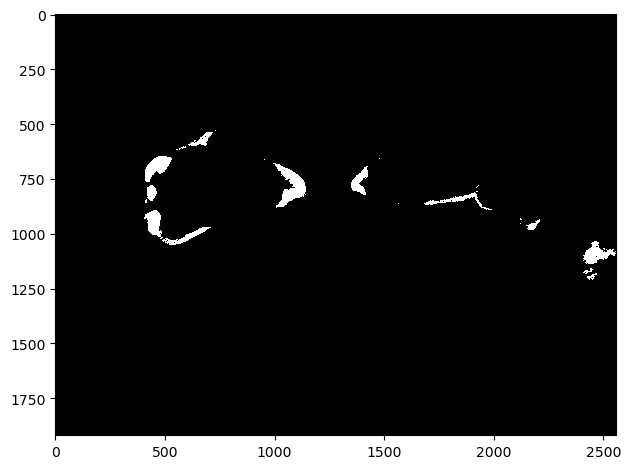

In [38]:
imshow(cart_mask)

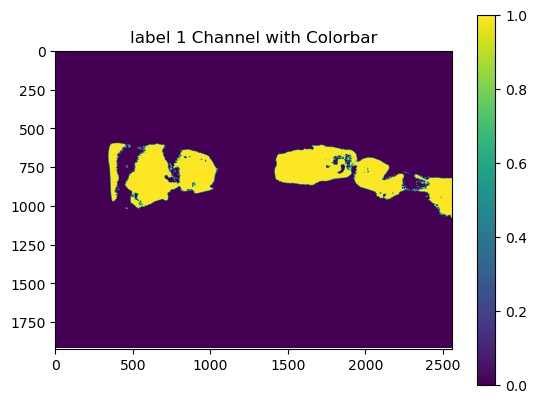

In [28]:
# Plot Hue Channel with Colorbar
plt.imshow(img_prob[:, :, 0] > 0.7)
plt.title('label 1 Channel with Colorbar')
plt.colorbar()
plt.show()

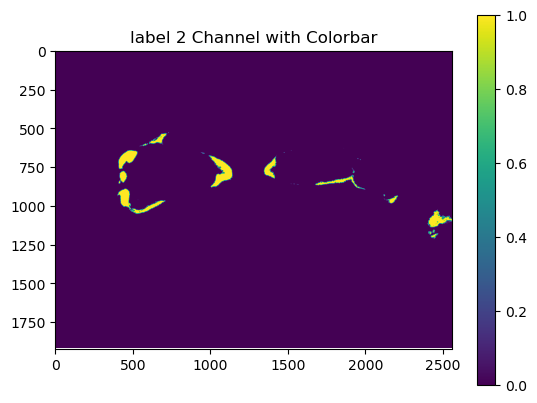

In [24]:
# Plot Hue Channel with Colorbar
plt.imshow(img_prob[:, :, 1] > 0.8)
plt.title('label 2 Channel with Colorbar')
plt.colorbar()
plt.show()